## **Importing the libraries**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings as ws
import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
ws.filterwarnings("ignore")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17756\473133589.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## **Loading the data**


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Krishil-Jayswal/AQI-Forecasting/refs/heads/main/2.%20Data%20Preprocessing/full_aqi_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [ ]:
df.head(10)

,PM2.5,PM10,NO2,NH3,SO2,CO,OZONE,AQI
Date,,,,,,,,
2019-05-01 00:00:00+00:00,81,140,13,2,28,22,23,140
2019-05-02 00:00:00+00:00,129,214,14,2,17,25,25,214
2019-05-03 00:00:00+00:00,89,144,11,2,17,13,43,144
2019-05-04 00:00:00+00:00,83,130,8,2,15,20,23,130
2019-05-05 00:00:00+00:00,78,116,6,2,13,27,25,116
2019-05-06 00:00:00+00:00,65,109,4,5,12,23,30,109
2019-05-07 00:00:00+00:00,62,105,6,4,13,34,8,105
2019-05-08 00:00:00+00:00,55,101,6,4,14,26,14,101
2019-05-09 00:00:00+00:00,58,104,8,2,34,22,21,104


## **Analyzing the Data**

Seasonal Pattern: There are visible recurring peaks and troughs, indicating potential seasonal trends in AQI levels, especially during certain times of the year (possibly winters showing higher AQI).

Early Dip: AQI values drop sharply in early 2019, which could be due to lockdown or other external factors (like pandemic restrictions).

Increasing Variability: From 2021 onwards, there appears to be increased fluctuations, with more extreme AQI values at certain points.

Recent Decline: Towards the end of the time series (late 2024–2025), there’s a visible decline in AQI, which might indicate improved air quality or policy interventions.


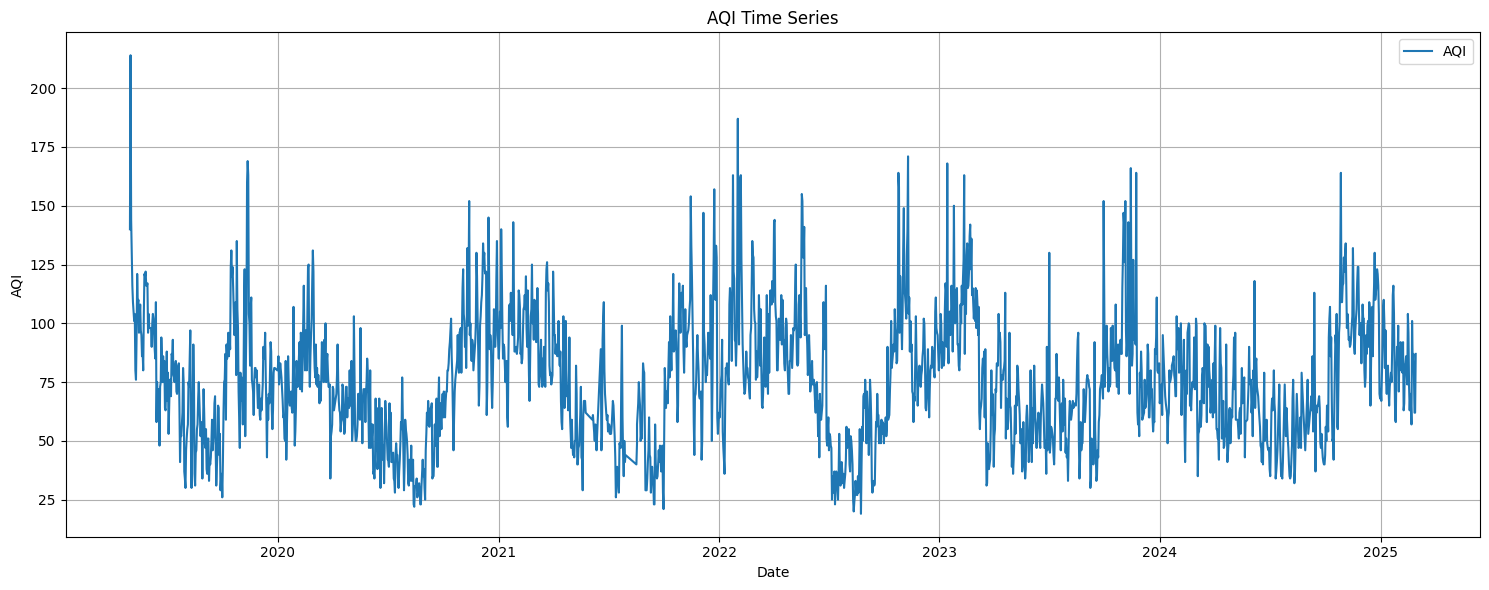

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df['AQI'], label='AQI')
plt.title('AQI Time Series' )
plt.xlabel('Date' )
plt.ylabel('AQI' )
plt.legend()

plt.xticks()
plt.yticks()

plt.grid(True)
plt.tight_layout()
plt.show()

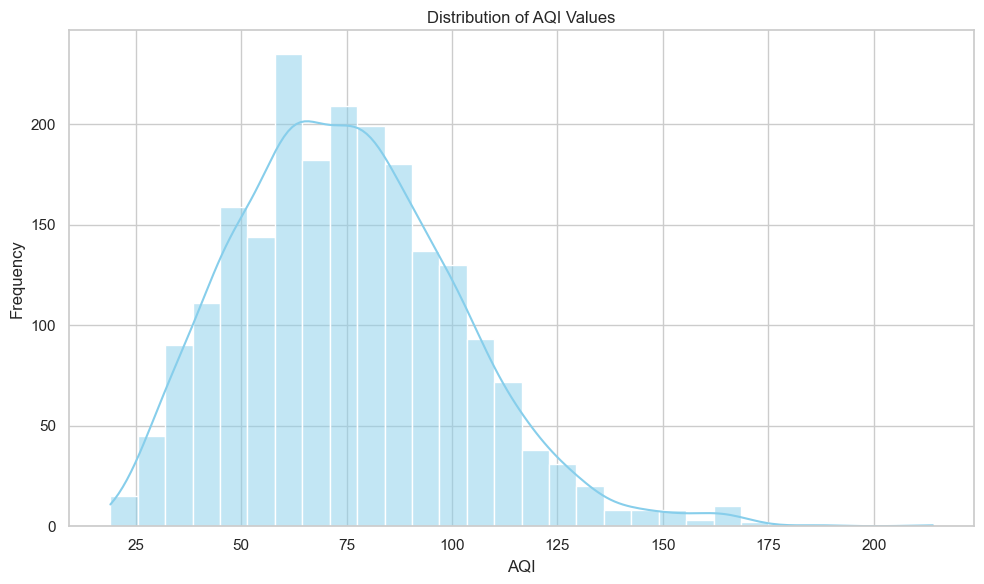

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['AQI'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of AQI Values' )
plt.xlabel('AQI' )
plt.ylabel('Frequency' )

plt.xticks()
plt.yticks()

plt.tight_layout()
plt.show()

From Histogram we can see that our AQI values are skewed. So log transformation can help us.


## **Distributional view of data**

We attempted to fit both the Normal and Cauchy distributions to our AQI data. From the plot below, it is evident that the Cauchy distribution does not fit the data well. While the Normal distribution provides a closer fit, it still does not perfectly capture the shape of the AQI distribution. So we are unable to determine the underlying distribution. If stationarity achieved so it will be weak stationarity as distribution is unknown.


Normal Distribution: mu=75.12435476302205, std=26.41754076124926


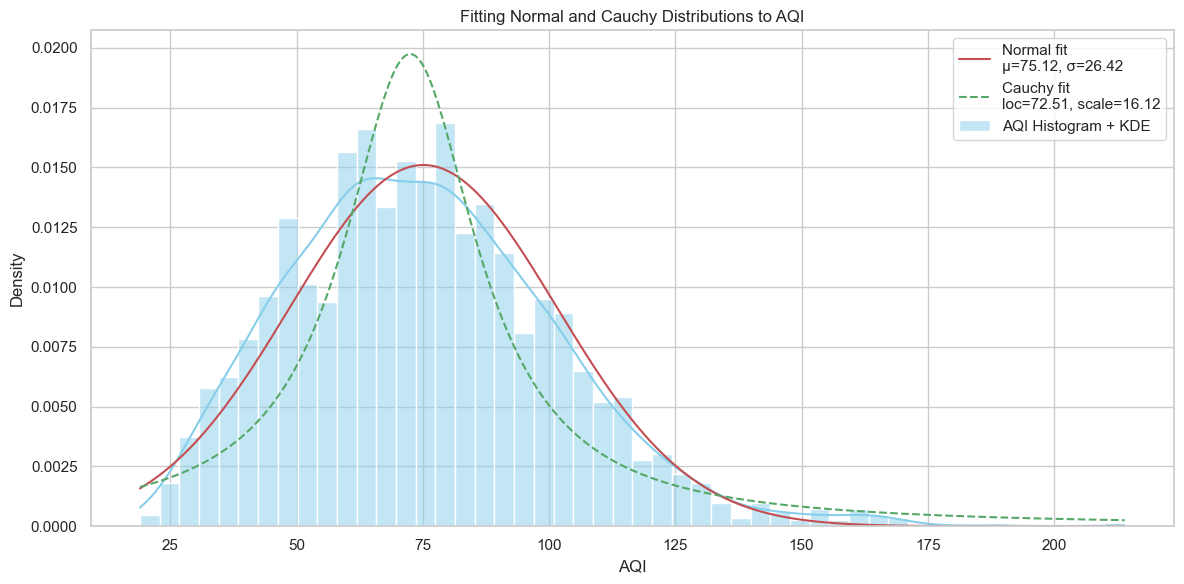

In [ ]:
from scipy.stats import norm, cauchy

aqi = df['AQI']

mu_norm, std_norm = norm.fit(aqi)
loc_cauchy, scale_cauchy = cauchy.fit(aqi)

print(f"Normal Distribution: mu={mu_norm}, std={std_norm}")

x = np.linspace(aqi.min(), aqi.max(), 1000)
pdf_norm = norm.pdf(x, mu_norm, std_norm)
pdf_cauchy = cauchy.pdf(x, loc_cauchy, scale_cauchy)

plt.figure(figsize=(12, 6))

sns.histplot(aqi, bins=50, kde=True, stat="density", color='skyblue', alpha=0.5, label="AQI Histogram + KDE")

plt.plot(x, pdf_norm, 'r-', label=f'Normal fit\nμ={mu_norm:.2f}, σ={std_norm:.2f}')
plt.plot(x, pdf_cauchy, 'g--', label=f'Cauchy fit\nloc={loc_cauchy:.2f}, scale={scale_cauchy:.2f}')

plt.title('Fitting Normal and Cauchy Distributions to AQI' )
plt.xlabel('AQI')
plt.ylabel('Density' )

plt.xticks()
plt.yticks()

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Baseline Models


In [ ]:
temp_df = df

In [ ]:
length = 100
x = temp_df['AQI'].iloc[:-length]
y = temp_df['AQI'].iloc[-length : ]

### Mean Forecast


In [ ]:
historical_mean = x.mean()

temp_df.loc[temp_df.index[-length:], 'historical_mean'] = historical_mean

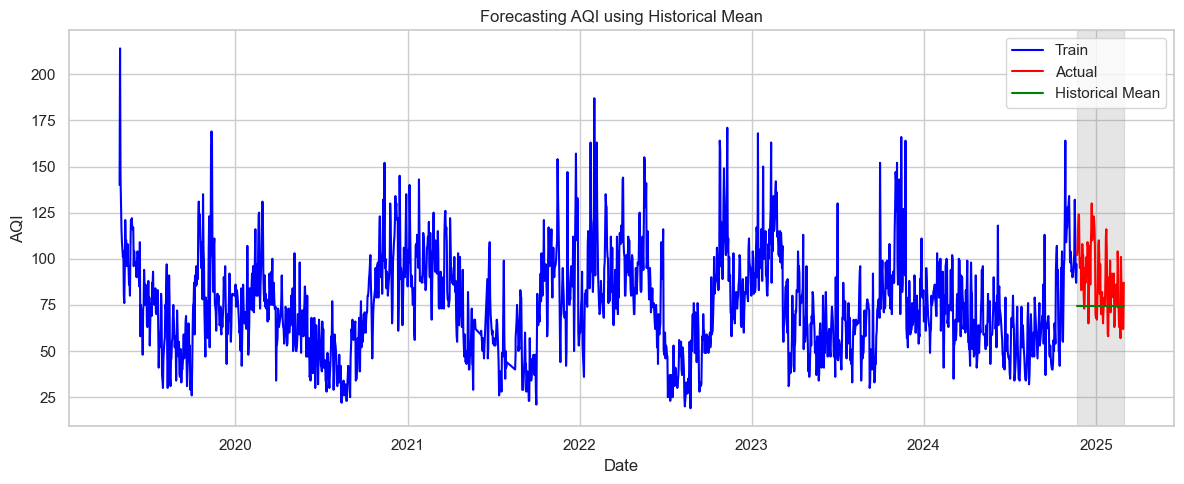

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(temp_df.index[:-length], temp_df['AQI'].iloc[:-length], color='blue', label='Train')
plt.plot(temp_df.index[-length:], y, color='red', label='Actual')
plt.plot(temp_df.index[-length:], temp_df['historical_mean'].iloc[-length:], color='green', label='Historical Mean')

plt.axvspan(temp_df.index[-length], temp_df.index[-1], color='gray', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('Forecasting AQI using Historical Mean')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
historical_mse = mean_squared_error(y, temp_df['historical_mean'].iloc[-length:])
historical_rmse = np.sqrt(historical_mse)
historical_mape = np.mean(np.abs((y - temp_df['historical_mean'].iloc[-length:]) / y)) * 100
historical_r2 = r2_score(y, temp_df['historical_mean'].iloc[-length:])
historical_mae = mean_absolute_error(y, temp_df['historical_mean'].iloc[-length:])

print(f"Historical Mean Forecast Evaluation:")
print(f"MSE  : {historical_mse:.2f}")
print(f"RMSE : {historical_rmse:.2f}")
print(f"MAPE : {historical_mape:.2f}%")
print(f"R²   : {historical_r2:.4f}")
print(f"MAE  : {historical_mae:.2f}")

Historical Mean Forecast Evaluation:
MSE  : 527.07
RMSE : 22.96
MAPE : 18.66%
R²   : -0.7077
MAE  : 18.24


### Naive Forecast


In [ ]:
temp_df['naive_forecast'] = temp_df['AQI'].shift(1)

naive_forecast = temp_df['naive_forecast'].iloc[-length:]
y_true = temp_df['AQI'].iloc[-length:]

In [ ]:
valid_idx = naive_forecast.dropna().index

naive_forecast = naive_forecast.loc[valid_idx]
y_true = y_true.loc[valid_idx]

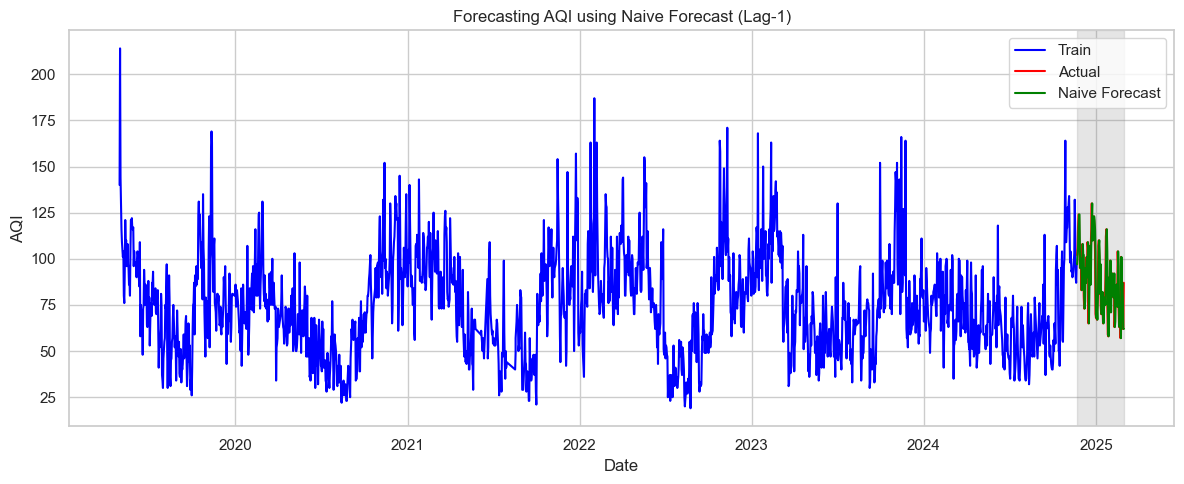

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(temp_df.index[:-length], temp_df['AQI'].iloc[:-length], color='blue', label='Train')
plt.plot(temp_df.index[-length:], temp_df['AQI'].iloc[-length:], color='red', label='Actual')
plt.plot(temp_df.index[-length:], temp_df['naive_forecast'].iloc[-length:], color='green', label='Naive Forecast')

plt.axvspan(temp_df.index[-length], temp_df.index[-1], color='gray', alpha=0.2)

plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('Forecasting AQI using Naive Forecast (Lag-1)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
naive_mse = mean_squared_error(y_true, naive_forecast)
naive_rmse = np.sqrt(naive_mse)
naive_mape = np.mean(np.abs((y_true - naive_forecast) / y_true)) * 100
naive_r2 = r2_score(y_true, naive_forecast)
naive_mae = mean_absolute_error(y_true, naive_forecast)

print(f"Naive Forecast (Lag-1) Evaluation:")
print(f"MSE  : {naive_mse:.2f}")
print(f"RMSE : {naive_rmse:.2f}")
print(f"MAPE : {naive_mape:.2f}%")
print(f"R²   : {naive_r2:.4f}")
print(f"MAE  : {naive_mae:.2f}")

Naive Forecast (Lag-1) Evaluation:
MSE  : 209.63
RMSE : 14.48
MAPE : 13.30%
R²   : 0.3257
MAE  : 11.33


### Drifting Method


In [ ]:

y_1 = x.iloc[0]
y_t = x.iloc[-1]
n = len(x)

length = min(length, len(temp_df))

drift_forecast = [y_t + (h + 1) * (y_t - y_1) / (n - 1) for h in range(length)]

if 'drift_forecast' not in temp_df.columns:
    temp_df['drift_forecast'] = np.nan

temp_df.iloc[-length:, temp_df.columns.get_loc('drift_forecast')] = drift_forecast

drift_series = temp_df['drift_forecast'].iloc[-length:]

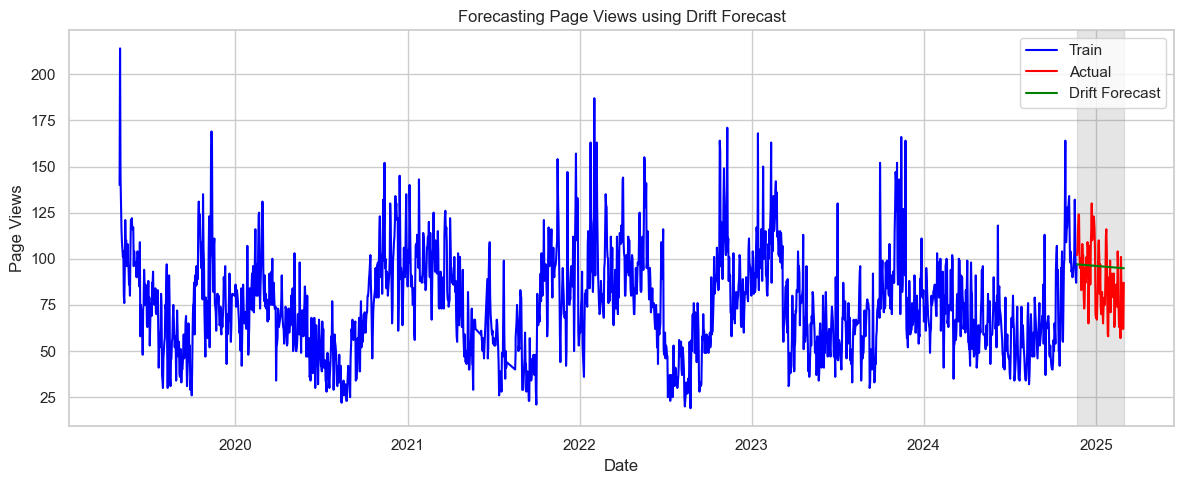

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(temp_df.index[:-length], temp_df['AQI'].iloc[:-length], color='blue', label='Train')
plt.plot(temp_df.index[-length:], y, color='red', label='Actual')
plt.plot(temp_df.index[-length:], drift_series, color='green', label='Drift Forecast')

plt.axvspan(temp_df.index[-length], temp_df.index[-1], color='gray', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Page Views')
plt.title('Forecasting Page Views using Drift Forecast')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
drift_mse = mean_squared_error(y, drift_series)
drift_rmse = np.sqrt(drift_mse)
drift_mape = np.mean(np.abs((y - drift_series) / y)) * 100
drift_r2 = r2_score(y, drift_series)
drift_mae = mean_absolute_error(y, drift_series)

print("Drift Forecast Evaluation:")
print(f"MSE  : {drift_mse:.2f}")
print(f"RMSE : {drift_rmse:.2f}")
print(f"MAPE : {drift_mape:.2f}%")
print(f"R²   : {drift_r2:.4f}")
print(f"MAE  : {drift_mae:.2f}")

Drift Forecast Evaluation:
MSE  : 343.41
RMSE : 18.53
MAPE : 19.79%
R²   : -0.1126
MAE  : 15.77


In [ ]:
models = ['Historical Mean', 'Naive Forecast', 'Drift Forecast']

rmse_values = [historical_rmse, naive_rmse, drift_rmse]
mae_values = [historical_mae, naive_mae, drift_mae]
r2_values = [historical_r2, naive_r2, drift_r2]
mape_values = [historical_mape, naive_mape, drift_mape]

In [ ]:
def plot_metric_bar(values, title, ylabel):
    x = np.arange(len(models))
    plt.figure(figsize=(8, 5))
    plt.bar(x, values, color='teal')
    plt.xticks(x, models, rotation=30, ha='right')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

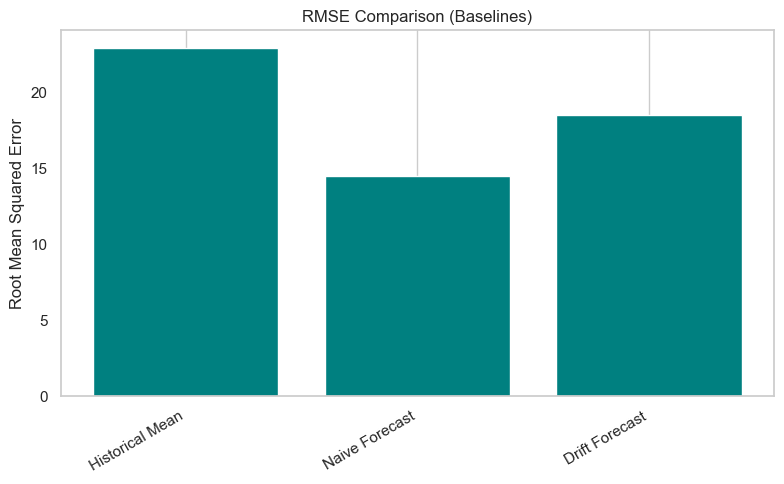

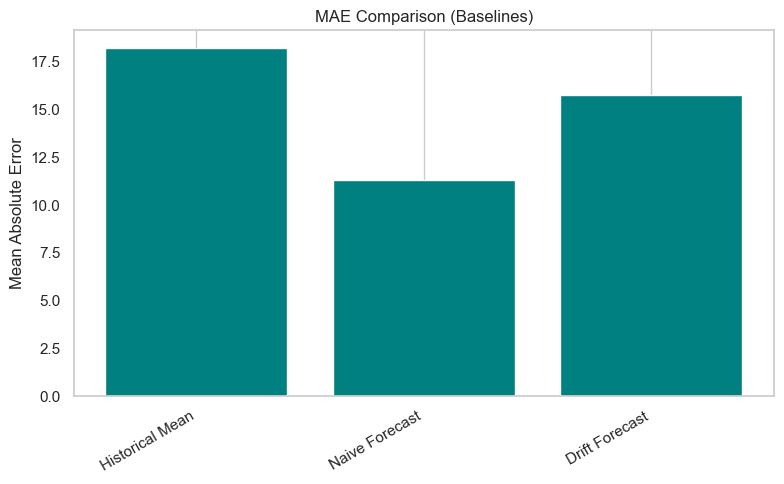

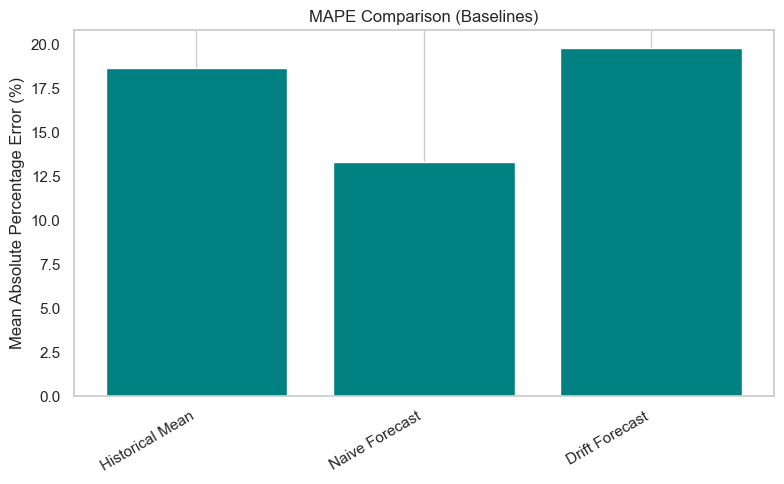

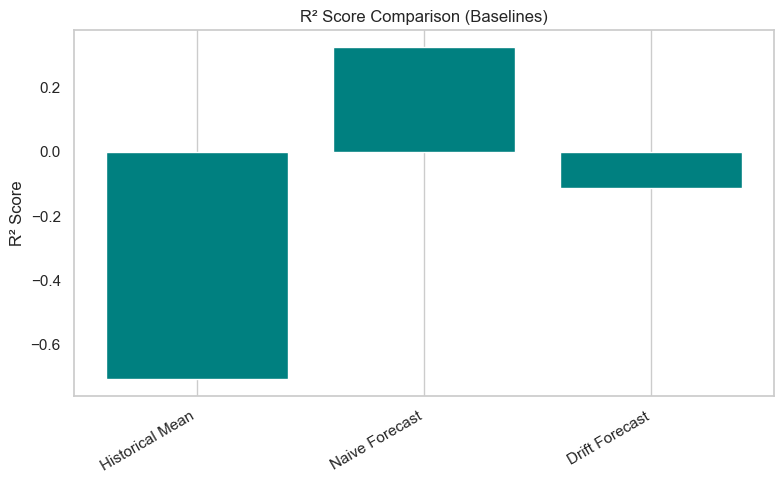

In [ ]:
plot_metric_bar(rmse_values, 'RMSE Comparison (Baselines)', 'Root Mean Squared Error')
plot_metric_bar(mae_values, 'MAE Comparison (Baselines)', 'Mean Absolute Error')
plot_metric_bar(mape_values, 'MAPE Comparison (Baselines)', 'Mean Absolute Percentage Error (%)')
plot_metric_bar(r2_values, 'R² Score Comparison (Baselines)', 'R² Score')

### **Step3: Analysing the data**


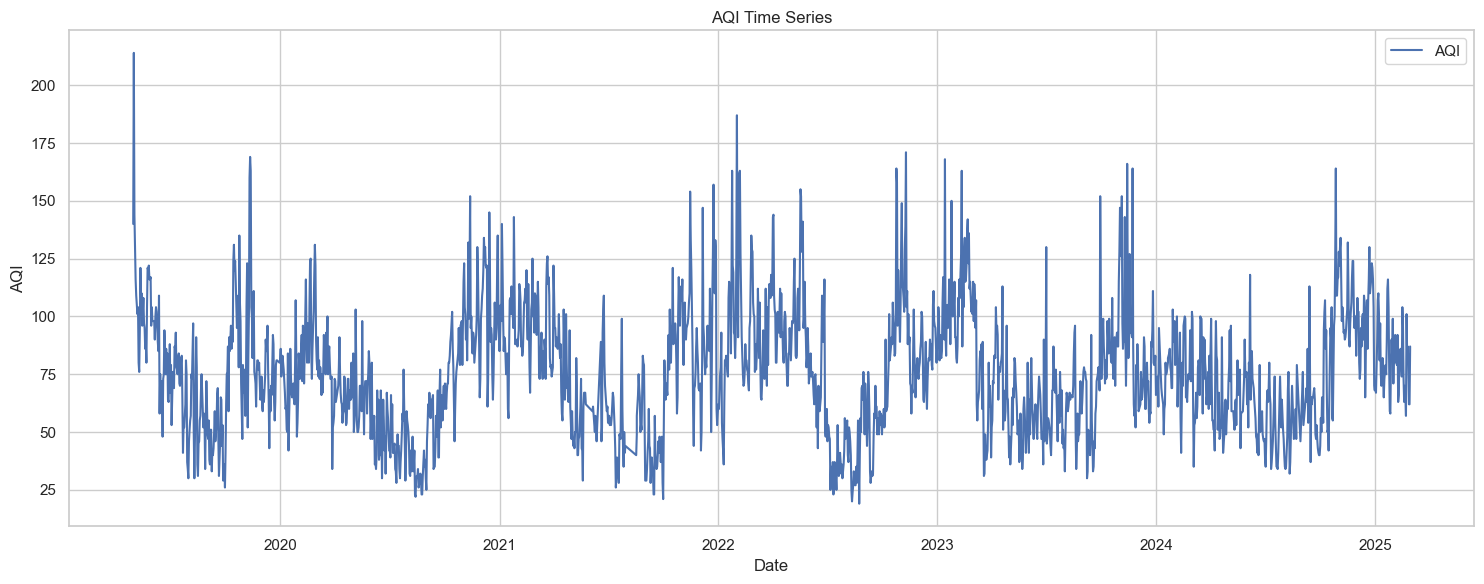

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df['AQI'], label='AQI')
plt.title('AQI Time Series' )
plt.xlabel('Date' )
plt.ylabel('AQI' )
plt.legend()

plt.xticks()
plt.yticks()

plt.grid(True)
plt.tight_layout()
plt.show()

Seasonal Pattern: There are visible recurring peaks and troughs, indicating potential seasonal trends in AQI levels, especially during certain times of the year (possibly winters showing higher AQI).

Early Dip: AQI values drop sharply in early 2019, which could be due to lockdown or other external factors (like pandemic restrictions).

Increasing Variability: From 2021 onwards, there appears to be increased fluctuations, with more extreme AQI values at certain points.

Recent Decline: Towards the end of the time series (late 2024–2025), there’s a visible decline in AQI, which might indicate improved air quality or policy interventions.


## **Decompostion of the data(Trend, seasonality, residuals)**

Additive Decomposition (Top Plot):
->Seasonal component has a constant amplitude (height of the peaks and troughs stays roughly the same) over time.

This implies that:

AQI = Trend + Seasonal + Residual

Multiplicative Decomposition (Bottom Plot):
->Seasonal component changes proportionally with the level of the series meaning the peaks and troughs of the seasonal component become larger when the AQI values are higher.

->Seasonality appears scaled with the trend.

This implies that:

AQI = Trend × Seasonal × Residual

Reason of plotting this both plots is to just see the nature of trend(linear/non-linear) and sesonality(period) of the series if any.


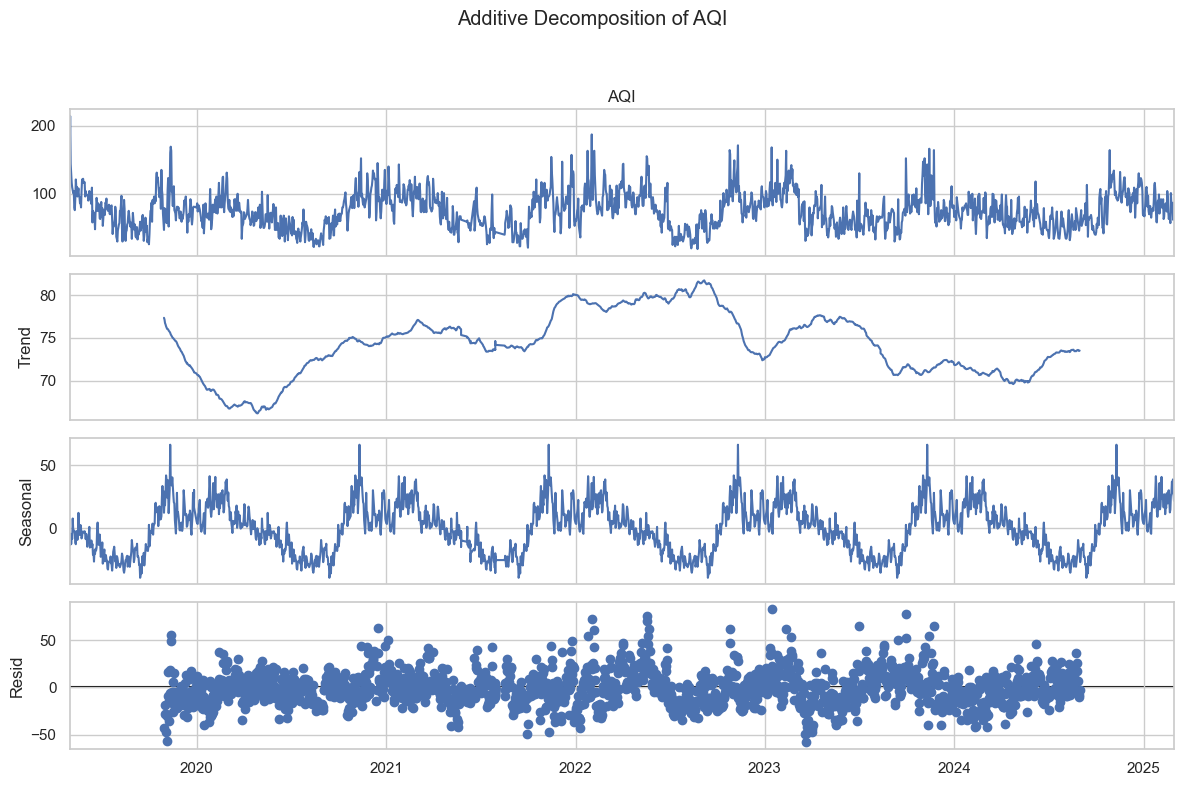

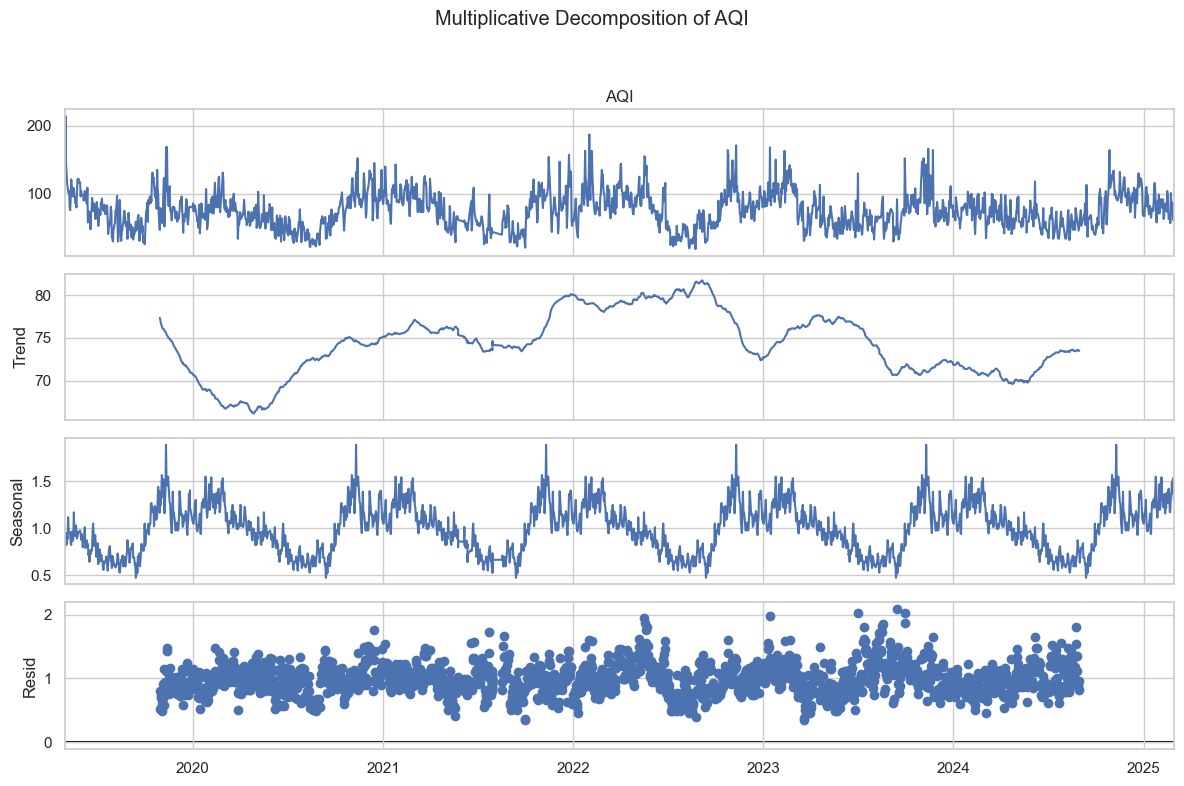

In [ ]:
result_add = seasonal_decompose(df['AQI'], model='additive', period=365)
fig = result_add.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Additive Decomposition of AQI')

for ax in fig.axes:
    ax.tick_params(axis='both')
    ax.set_ylabel(ax.get_ylabel())

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

result_mult = seasonal_decompose(df['AQI'], model='multiplicative', period=365)
fig = result_mult.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Multiplicative Decomposition of AQI')

for ax in fig.axes:
    ax.tick_params(axis='both')
    ax.set_ylabel(ax.get_ylabel())

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## **Stationarity checking**

A time series is stationary if its mean, variance remain constant over time and autocorrelation (ACF) depend on time lag only.

Mean: Should not show upward or downward trends(constant across series).

Variance: Should remain stable across the series.

ACF: Should drop off quickly if the series is stationary(should depend only on the lag paramter not on the time).

If these properties change over time, the series is non-stationary and needs transformations like differencing or log transformation to stabilize it.

And we used a rolling window of 30 days because our AQI data is on a daily scale, and a 30-day window helps us capture broader monthly trends while smoothing out short-term fluctuations. In air quality studies, 30-day windows are often used because monthly patterns (festivals, weather cycles, crop burning) affect AQI. This makes it easier to analyze seasonal variations and check for consistency or changes in the mean and variance over time. A 7-day window would be too sensitive to weekly changes it might catch short-term noise rather than meaningful trends. On the other hand, a 60-day window would smooth the data too much and potentially hide important month-wise patterns. So, 30 days is a balanced choice long enough to reduce noise, but short enough to capture meaningful variation in AQI on a monthly basis.


In [ ]:
result = adfuller(df['AQI'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

p_value = result[1]
if p_value < 0.05:
    print("Time series is stationary")
else:
    print("Time series is non-stationary")

ADF Statistic: -5.044799
p-value: 0.000018
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
Time series is stationary


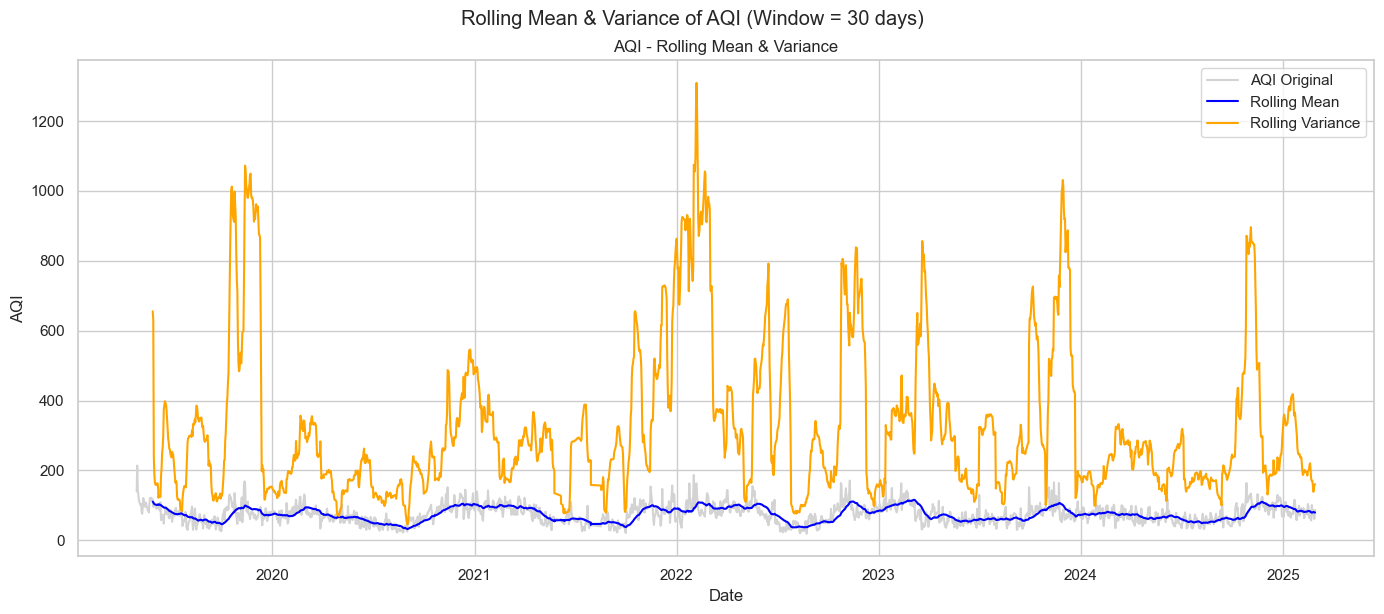

In [ ]:
window = 30

plt.figure(figsize=(14, 6))
plt.plot(df['AQI'], label=f'{"AQI"} Original', color='lightgray')
plt.plot(df['AQI'].rolling(window).mean(), label='Rolling Mean', color='blue')
plt.plot(df['AQI'].rolling(window).var(), label='Rolling Variance', color='orange')
plt.title(f'{"AQI"} - Rolling Mean & Variance' )
plt.xlabel('Date' )
plt.xticks()
plt.ylabel('AQI')
plt.yticks()
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.suptitle('Rolling Mean & Variance of AQI (Window = 30 days)',  y=1.02)
plt.show()

## **Data transformation**

Since our series is skewed and also the variance have huge fluctuations so we will take a log transformation on it. And then check for stationarity, if not yet so we will then use methods like

-MA method

-Differencing method

In our case we will use differencing method. We then again check for stationarity using mean, variance and ACF.


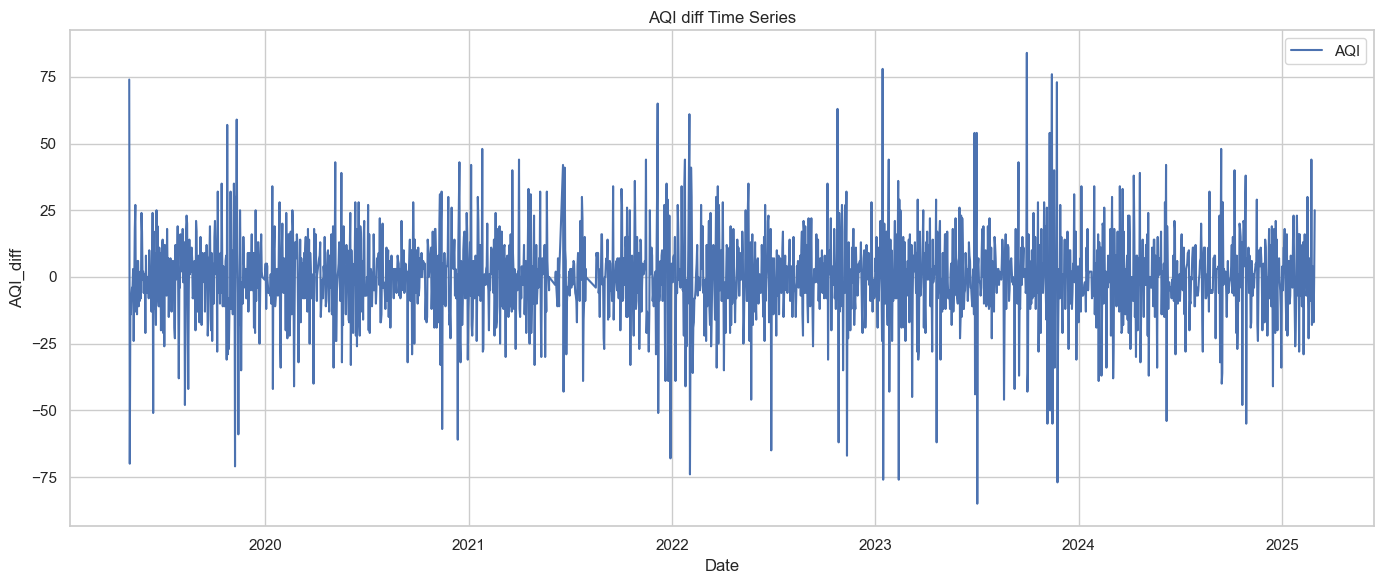

In [ ]:
df['AQI_diff'] = df['AQI'].diff()

plt.figure(figsize=(14, 6))
plt.plot(df['AQI_diff'], label='AQI')
plt.title('AQI diff Time Series' )
plt.xlabel('Date', )
plt.xticks()
plt.ylabel('AQI_diff' )
plt.yticks()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

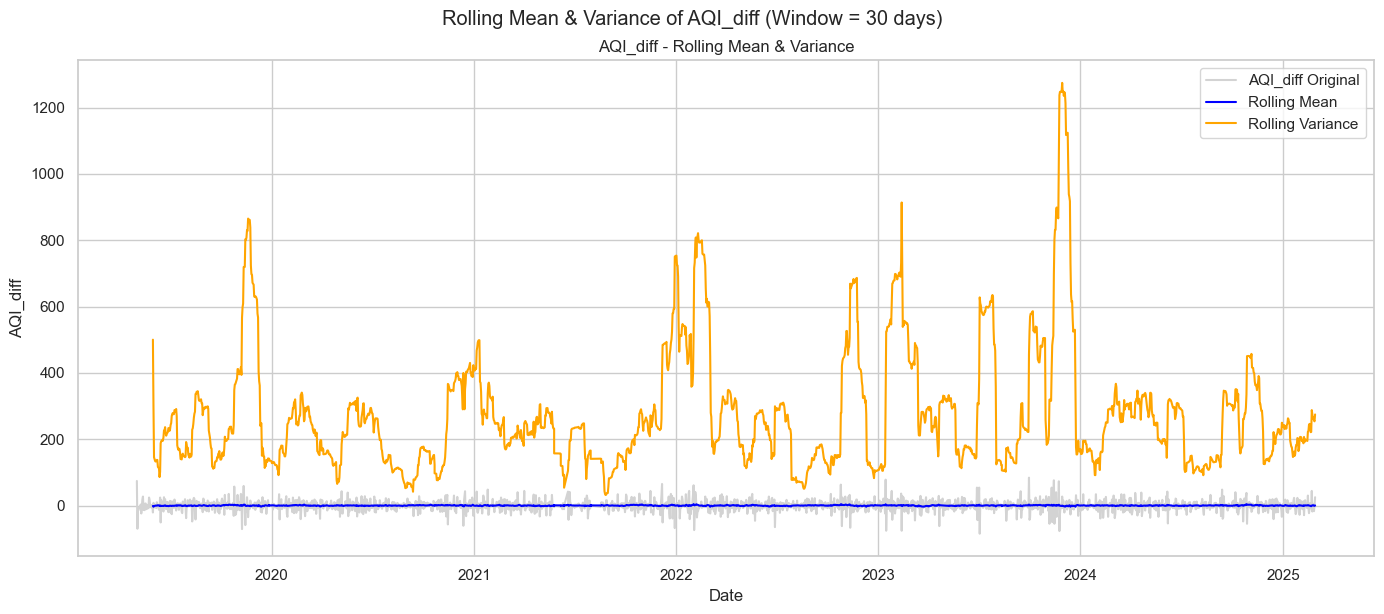

In [ ]:
window = 30
plt.figure(figsize=(14, 6))
plt.plot(df['AQI_diff'], label=f'{"AQI_diff"} Original', color='lightgray')
plt.plot(df['AQI_diff'].rolling(window).mean(), label='Rolling Mean', color='blue')
plt.plot(df['AQI_diff'].rolling(window).var(), label='Rolling Variance', color='orange')
plt.title(f'{"AQI_diff"} - Rolling Mean & Variance' )
plt.xlabel('Date' )
plt.xticks()
plt.ylabel('AQI_diff' )
plt.yticks()
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.suptitle('Rolling Mean & Variance of AQI_diff (Window = 30 days)',  y=1.02)
plt.show()

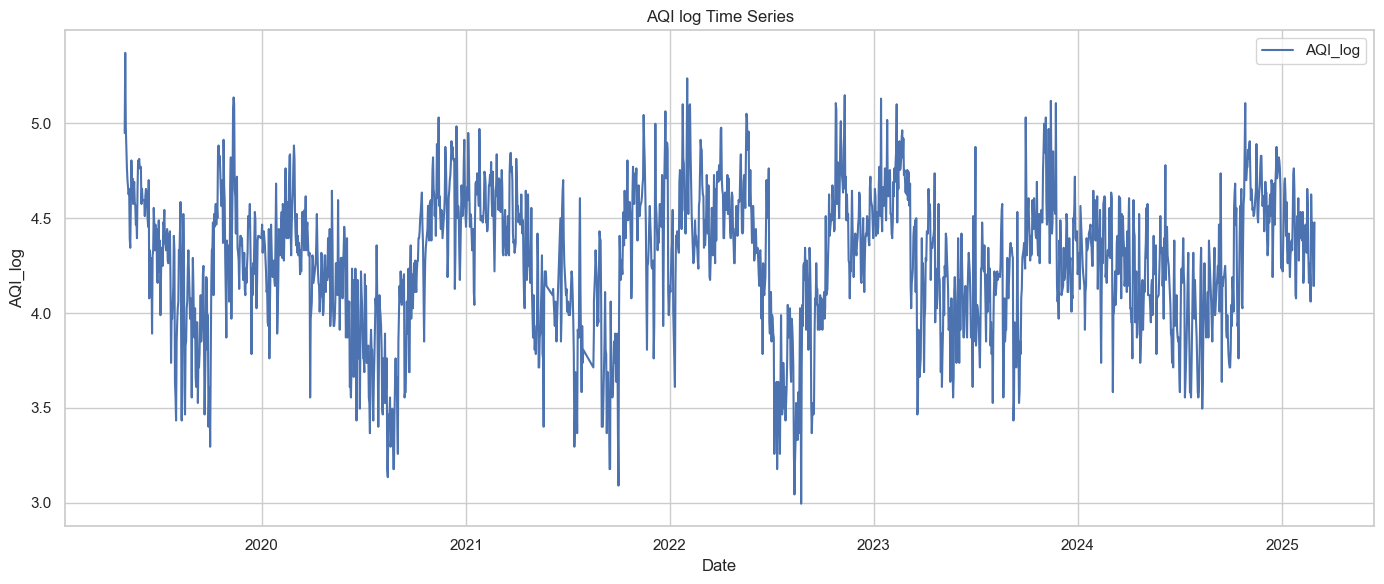

In [ ]:
df['AQI_log'] = np.log(df['AQI'] + 1)
plt.figure(figsize=(14, 6))
plt.plot(df['AQI_log'], label='AQI_log')
plt.title('AQI log Time Series' )
plt.xlabel('Date' )
plt.xticks()
plt.ylabel('AQI_log' )
plt.yticks()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

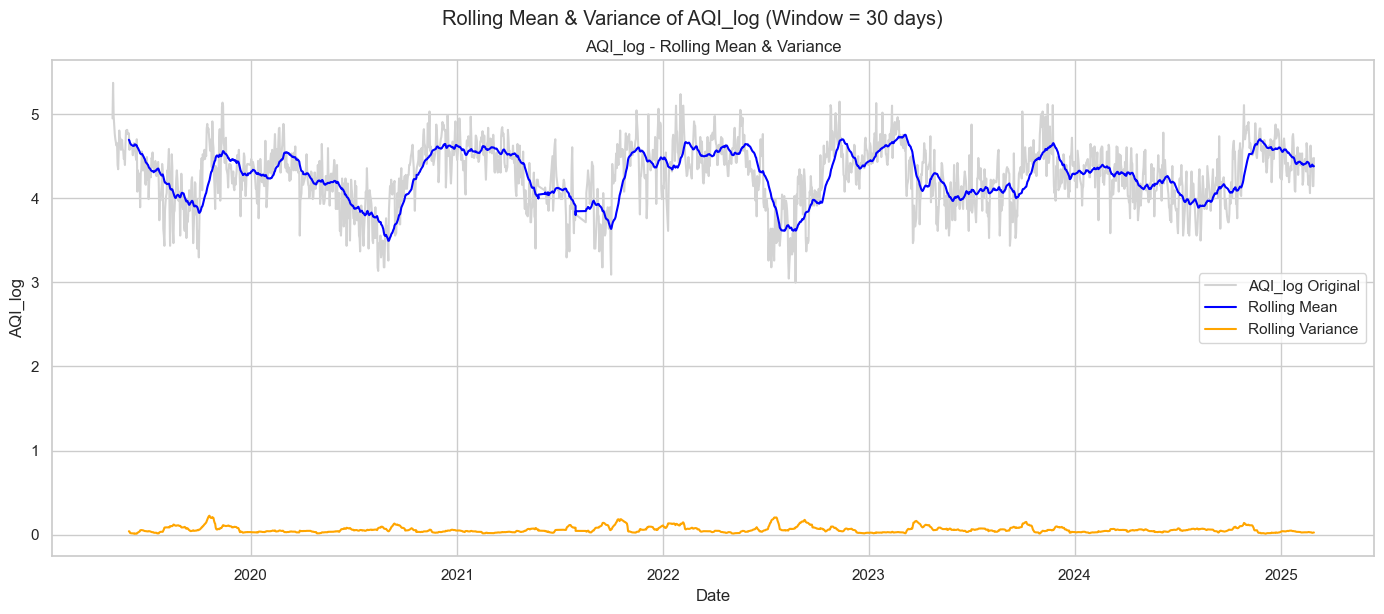

In [ ]:
window = 30
plt.figure(figsize=(14, 6))
plt.plot(df['AQI_log'], label=f'{"AQI_log"} Original', color='lightgray')
plt.plot(df['AQI_log'].rolling(window).mean(), label='Rolling Mean', color='blue')
plt.plot(df['AQI_log'].rolling(window).var(), label='Rolling Variance', color='orange')
plt.title(f'{"AQI_log"} - Rolling Mean & Variance' )
plt.xlabel('Date' )
plt.ylabel('AQI_log' )
plt.xticks()
plt.yticks()
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.suptitle('Rolling Mean & Variance of AQI_log (Window = 30 days)', y=1.02)
plt.show()

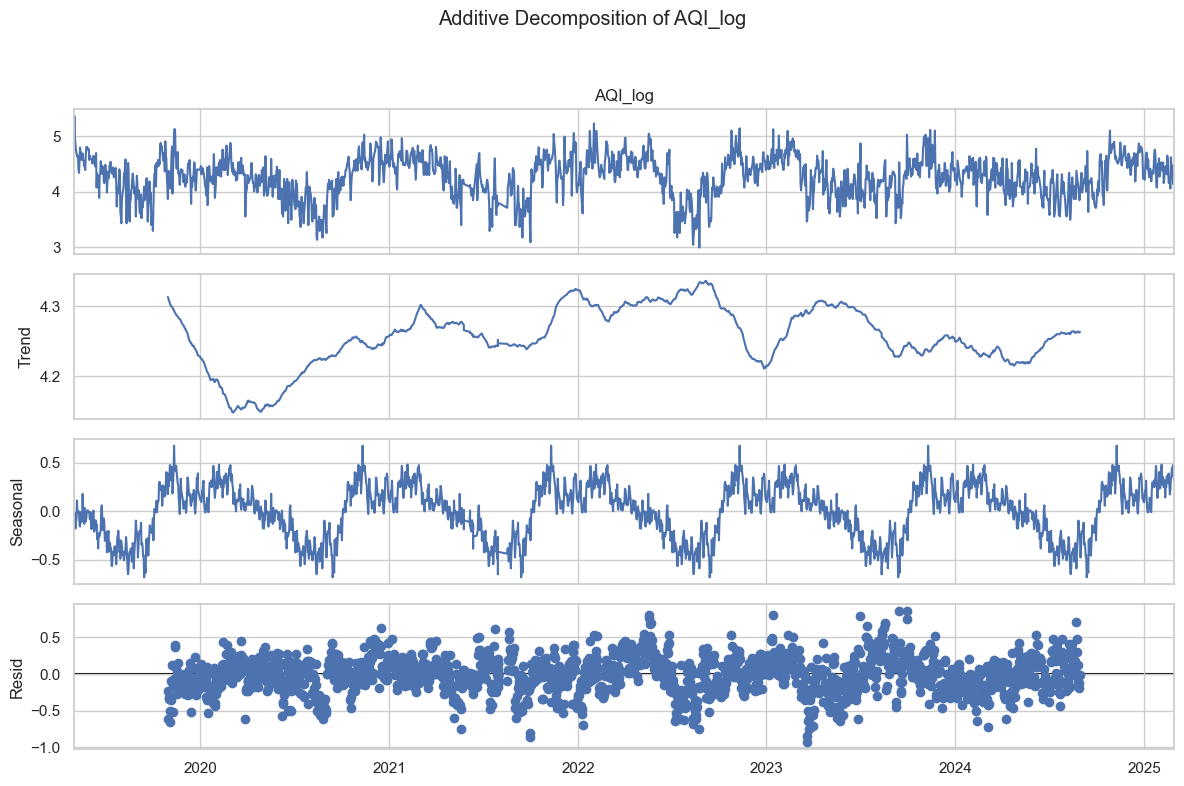

In [ ]:
result_add = seasonal_decompose(df['AQI_log'], model='additive', period=365)
fig = result_add.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Additive Decomposition of AQI_log' )

for ax in fig.axes:
    ax.tick_params(axis='both')
    ax.set_ylabel(ax.get_ylabel() )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Here our variance is stabilized, now we are stabilizing the mean.


## **Differencing Method used to make stationary data**


In [ ]:
df['AQI_log_diff'] = df['AQI_log'].diff()

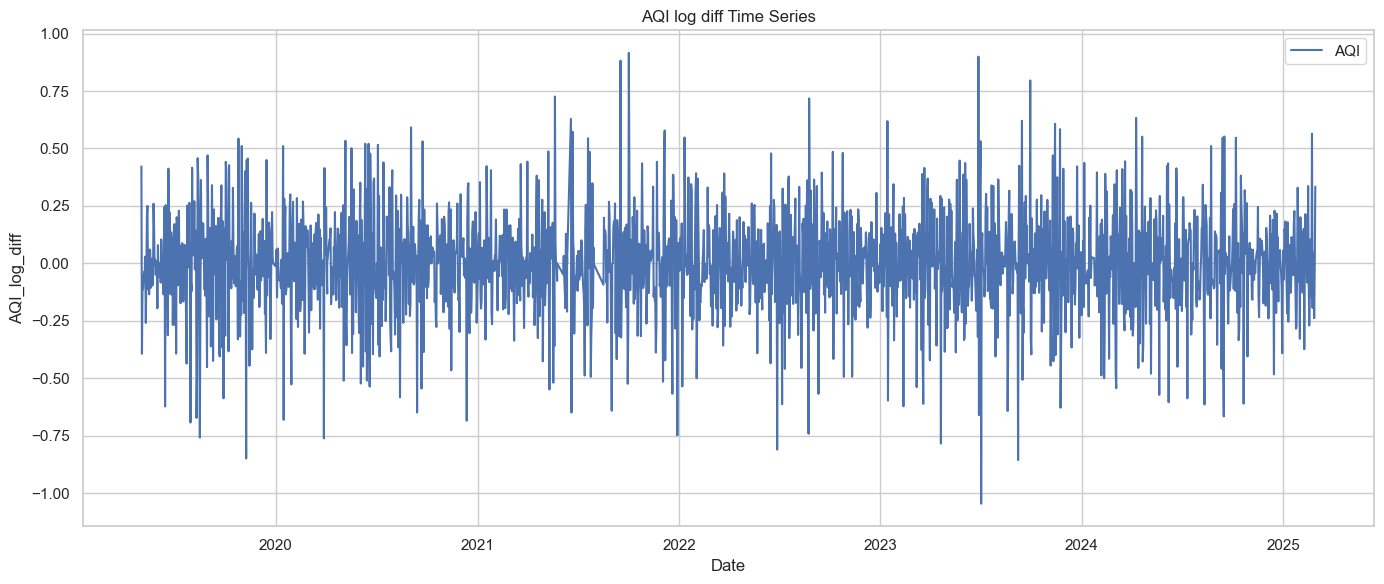

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df['AQI_log_diff'], label='AQI')
plt.title('AQI log diff Time Series' )
plt.xlabel('Date' )
plt.xticks()
plt.ylabel('AQI_log_diff' )
plt.yticks()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

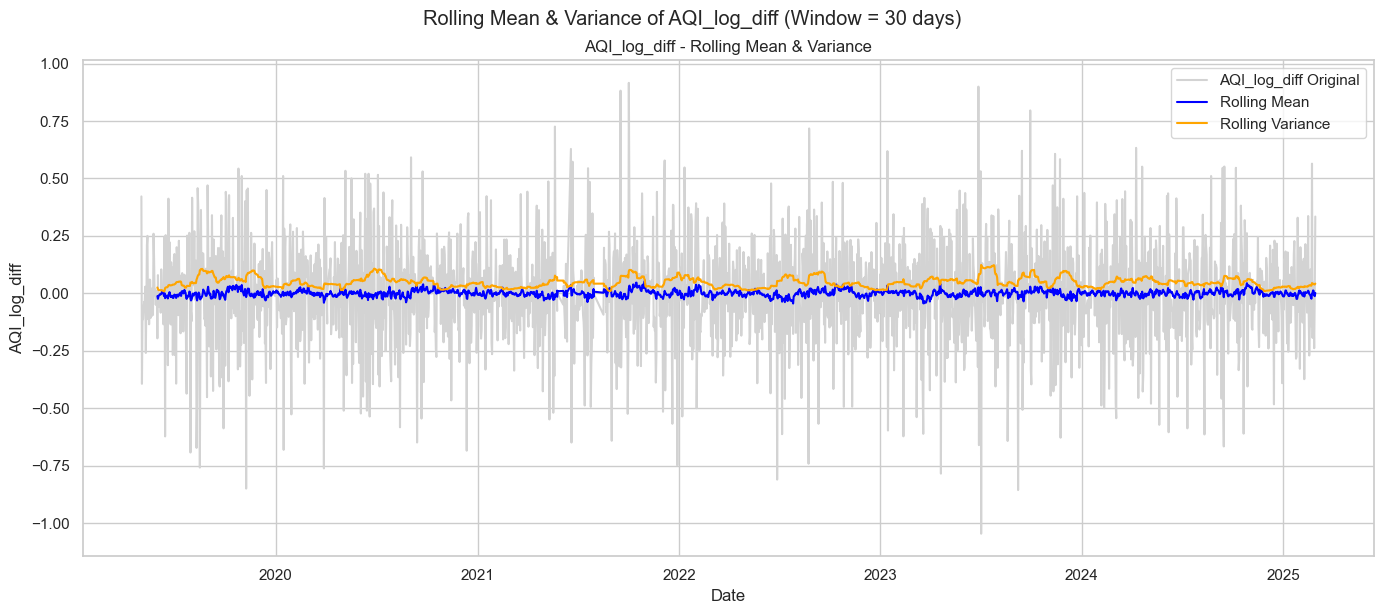

In [ ]:
window = 30
plt.figure(figsize=(14, 6))
plt.plot(df['AQI_log_diff'], label=f'{"AQI_log_diff"} Original', color='lightgray')
plt.plot(df['AQI_log_diff'].rolling(window).mean(), label='Rolling Mean', color='blue')
plt.plot(df['AQI_log_diff'].rolling(window).var(), label='Rolling Variance', color='orange')
plt.title(f'{"AQI_log_diff"} - Rolling Mean & Variance')
plt.xlabel('Date')
plt.ylabel('AQI_log_diff' )
plt.xticks()
plt.yticks()
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.suptitle('Rolling Mean & Variance of AQI_log_diff (Window = 30 days)', y=1.02)
plt.show()

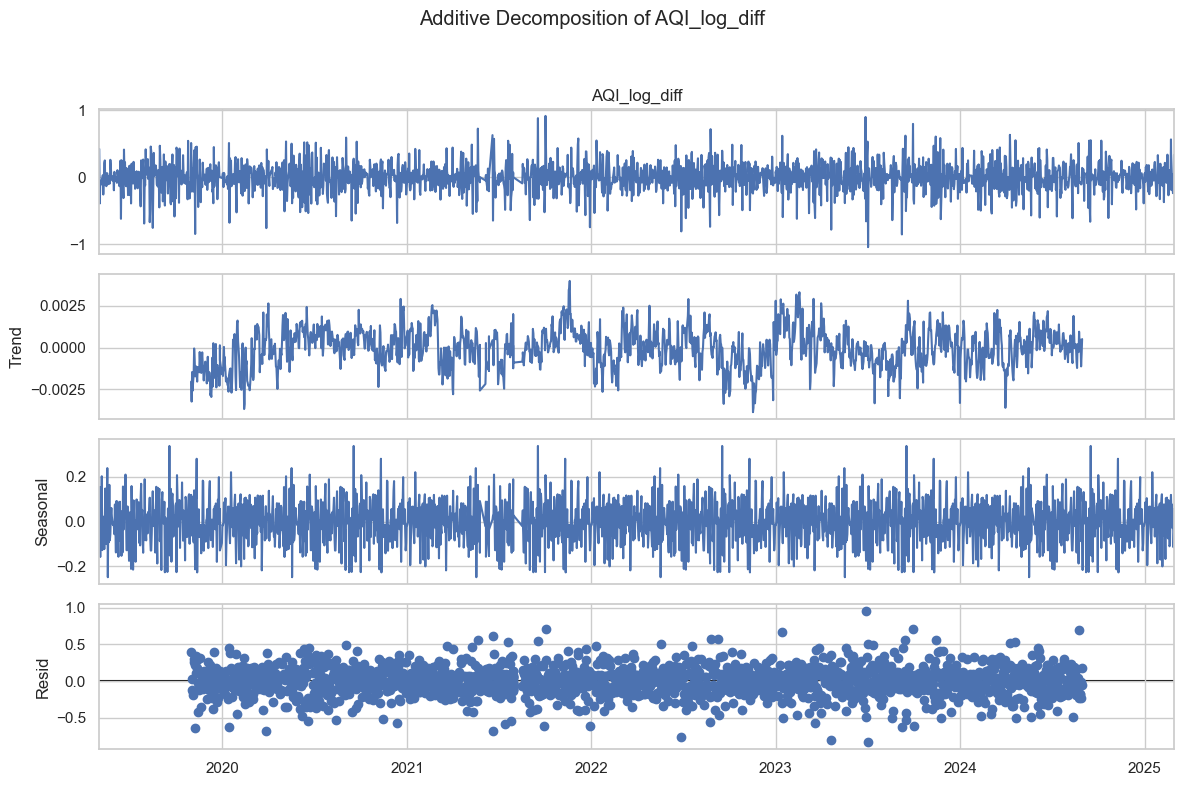

In [ ]:
result_add = seasonal_decompose(df['AQI_log_diff'].dropna(), model='additive', period=365)
fig = result_add.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Additive Decomposition of AQI_log_diff' )

for ax in fig.axes:
    ax.tick_params(axis='both')
    ax.set_ylabel(ax.get_ylabel() )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### **Plotting ACF to verify stationarity**

The ACF plot helps check stationarity by showing the correlation of the series with its past values.
If the ACF drops off quickly (i.e., few significant lags), the series is likely stationary.
If it declines slowly, the series may be non-stationary.

In the original AQI series, the ACF declines slowly, indicating non-stationarity.
In the AQI_diff series, although only a few lags are significant, the variance fluctuates, so it cannot be considered stationary.
In the AQI_log_diff series, we observe three significant lags (suggesting a possible MA(2) or MA(3) process), and both the mean and variance appear nearly constant.
Therefore, we can consider AQI_log_diff to be a stationary series.


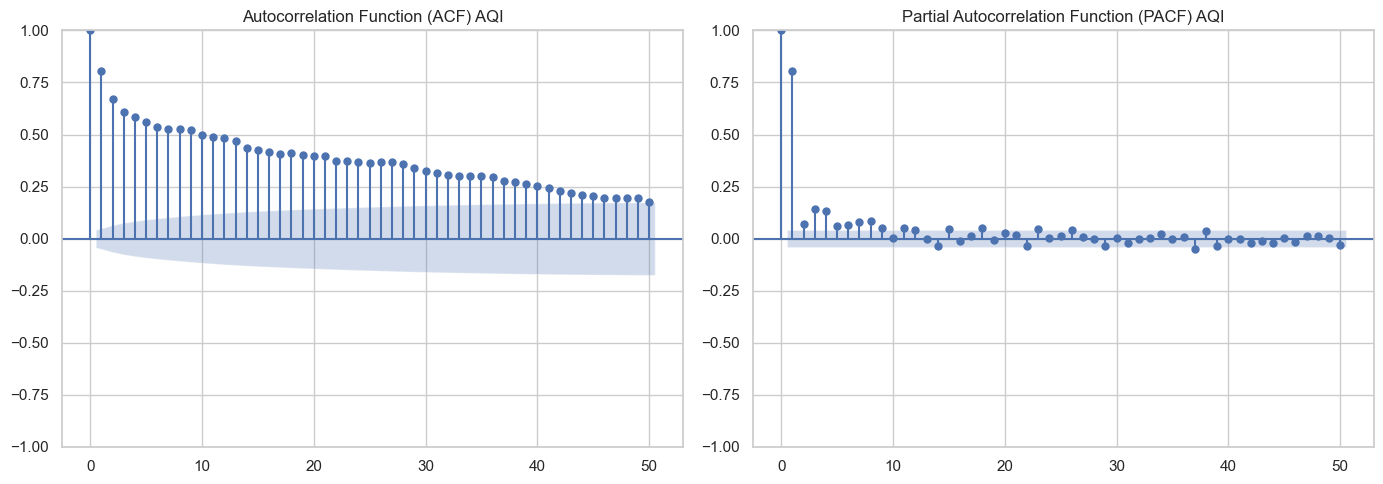

In [ ]:
series = df['AQI'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) AQI")

plot_pacf(series, lags=50, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF) AQI")

plt.tight_layout()
plt.show()

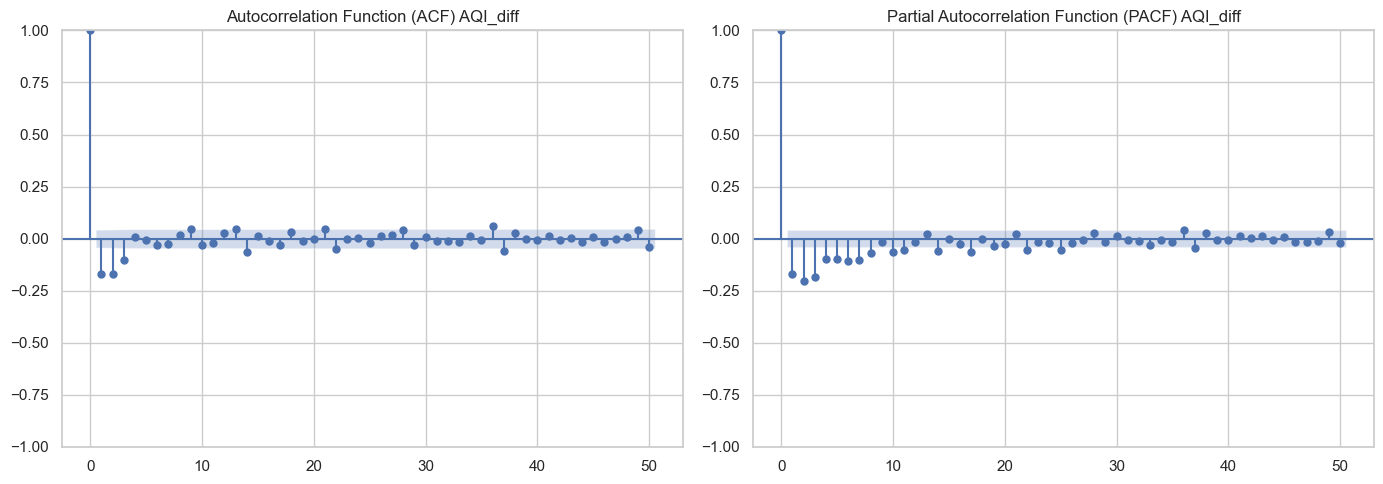

In [ ]:
series = df['AQI_diff'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) AQI_diff")

plot_pacf(series, lags=50, ax=axes[1], method='ywm')  # ywm = Yule-Walker Modified (safe default)
axes[1].set_title("Partial Autocorrelation Function (PACF) AQI_diff")

plt.tight_layout()
plt.show()

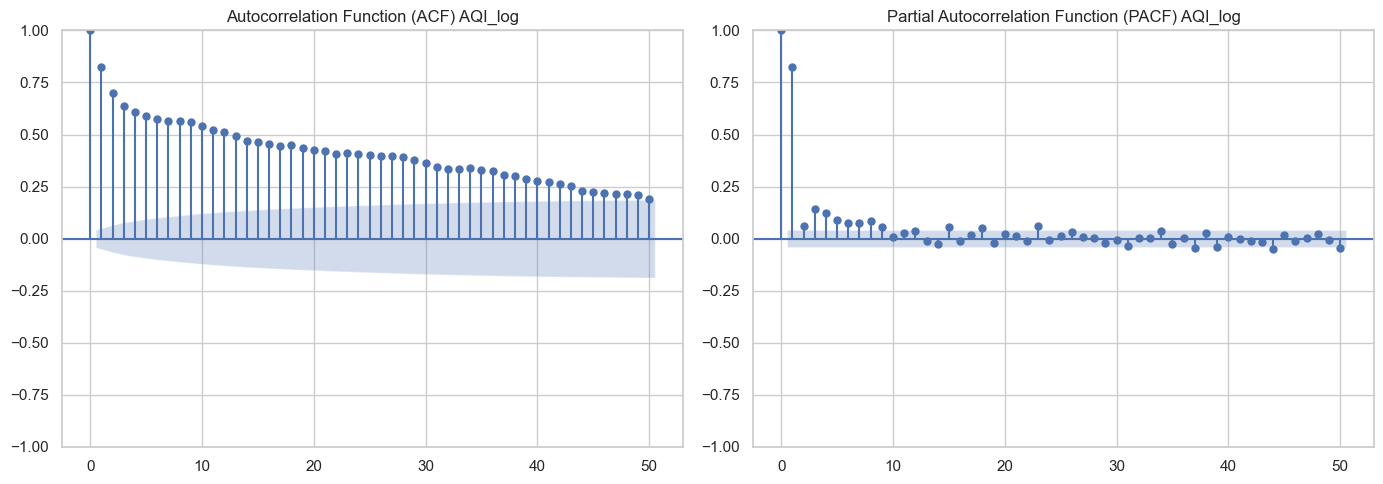

In [ ]:
series = df['AQI_log'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) AQI_log")

plot_pacf(series, lags=50, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF) AQI_log")

plt.tight_layout()
plt.show()

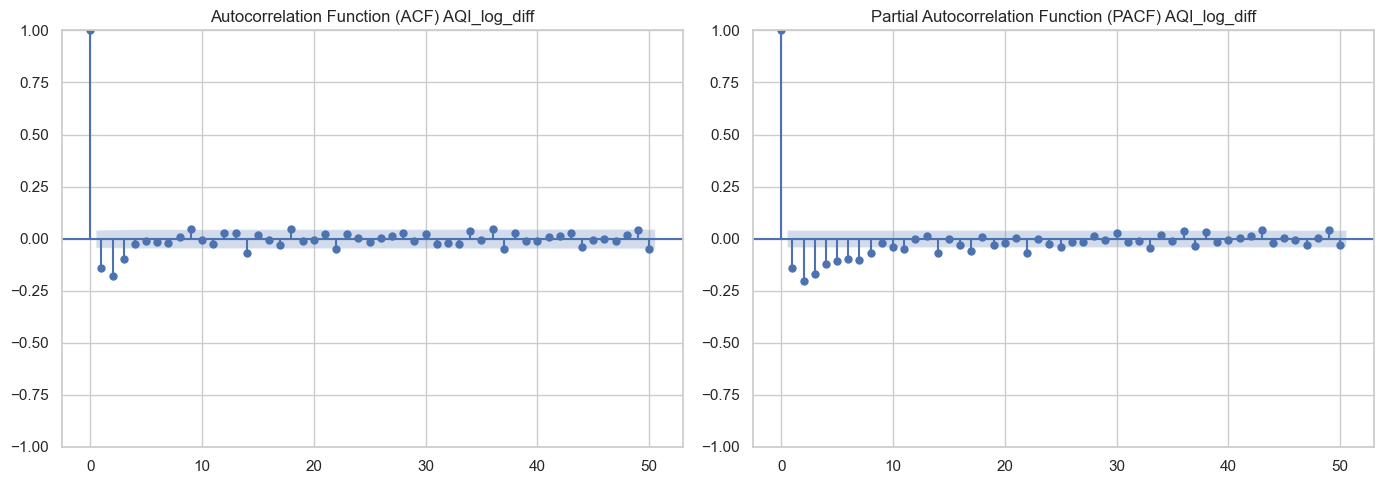

In [ ]:
series = df['AQI_log_diff'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) AQI_log_diff")

plot_pacf(series, lags=50, ax=axes[1], method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF) AQI_log_diff")

plt.tight_layout()
plt.show()

## **Model Selection and Fitting**

Since the AQI_log_diff series is stationary, it is suitable for model fitting. We consider an ARIMA(p,1,q).

Alternatively, AR(p) part is some and the differencing order is set to one, allowing the model to handle differencing internally. The MA component remains unchanged.

Using ARIMA(p,1,q) simplifies the process, as the model takes care of differencing automatically. However, since the predictions will be in the log-transformed scale, we need to invert them using the exponential function to get the forecasted AQI values on the original scale.


In [ ]:
def find_optimal_arima_params(series, max_p=5, max_q=5):
    best_aic = float("inf")
    best_order = None
    best_model = None

    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        if p == 0 and q == 0:
            continue
        try:
            model = ARIMA(series, order=(p, 0, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_order = (p, q)
                best_model = model
        except Exception as e:
            print(f"Error for (p,q)=({p},{q}): {e}")

    return best_order, best_model,best_aic

In [ ]:
best_order,best_model,best_aic = find_optimal_arima_params(df['AQI_log_diff'])

print(f"Best ARIMA model order: {best_order} with AIC = {best_aic}")

Best ARIMA model order: (2, 1) with AIC = -818.7156065403806


## **Verifying residuals characteristics**

To validate our model, we analyze the residuals. Ideally, residuals should resemble white noise normally distributed, with constant variance and no autocorrelation.

Q-Q plot: Shows residuals are nearly normally distributed(tail parts may show some divergence).

ACF plot: No significant lags, indicating residuals are uncorrelated.

Histogram: Supports normality with a bell-shaped distribution.

These characteristics confirm that the model has captured the structure in the data well.


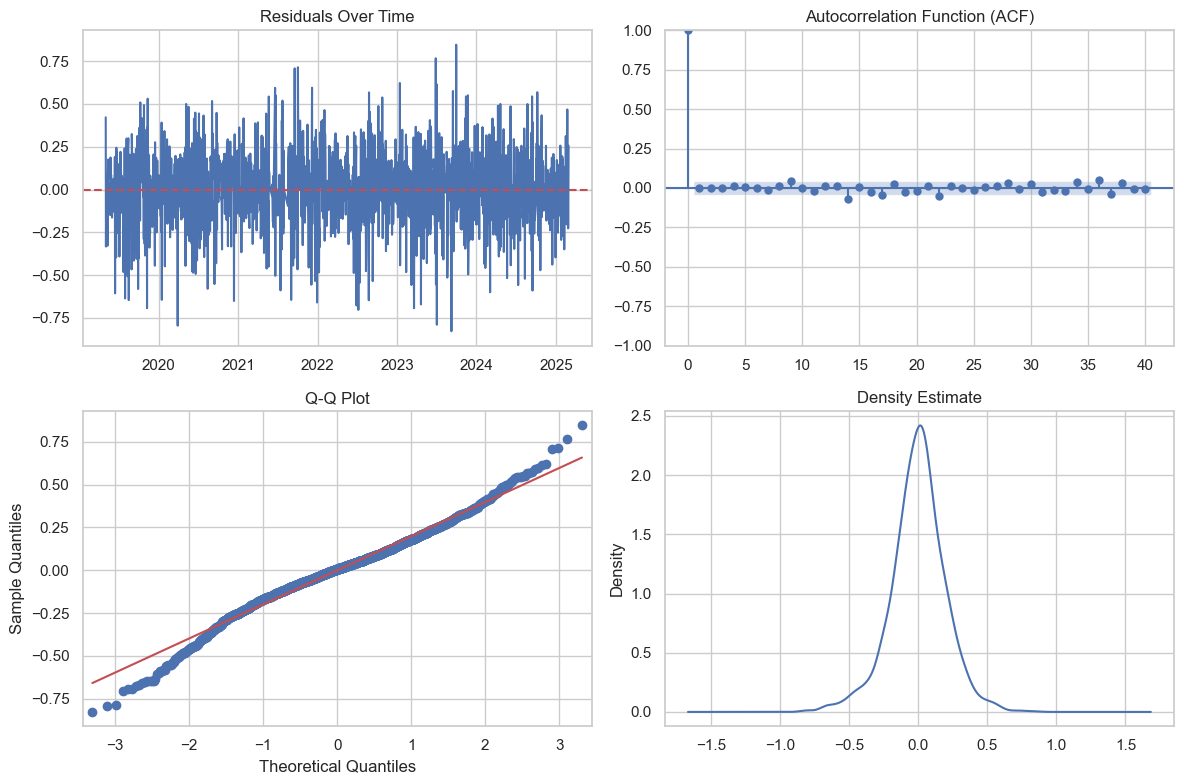

In [ ]:
def plot_residual_diagnostics(model_results, figsize=(12, 8)):
    """
    Plot diagnostic plots for ARIMA model residuals
    """
    residuals = model_results.resid.dropna()

    plt.figure(figsize=figsize)

    plt.subplot(2, 2, 1)
    plt.plot(residuals)
    plt.title('Residuals Over Time')
    plt.axhline(y=0, color='r', linestyle='--')

    plt.subplot(2, 2, 2)
    sm.graphics.tsa.plot_acf(residuals, lags=40, ax=plt.gca())
    plt.title('Autocorrelation Function (ACF)')

    plt.subplot(2, 2, 3)
    qqplot(residuals, line='s', ax=plt.gca())
    plt.title('Q-Q Plot')

    plt.subplot(2, 2, 4)
    residuals.plot(kind='kde')
    plt.title('Density Estimate')

    plt.tight_layout()
    plt.show()

plot_residual_diagnostics(best_model)

## **AQI Forecast using ARIMA**


In [ ]:
split_point = int(len(df) * 0.8)
train = df['AQI_log'].iloc[:split_point]
test = df['AQI_log'].iloc[split_point:]

print(f"Training set: {len(train)} samples ({train.index.min()} to {train.index.max()})")
print(f"Test set: {len(test)} samples ({test.index.min()} to {test.index.max()})")

Training set: 1704 samples (2019-05-01 00:00:00+00:00 to 2023-12-29 00:00:00+00:00)
Test set: 427 samples (2023-12-30 00:00:00+00:00 to 2025-02-28 00:00:00+00:00)


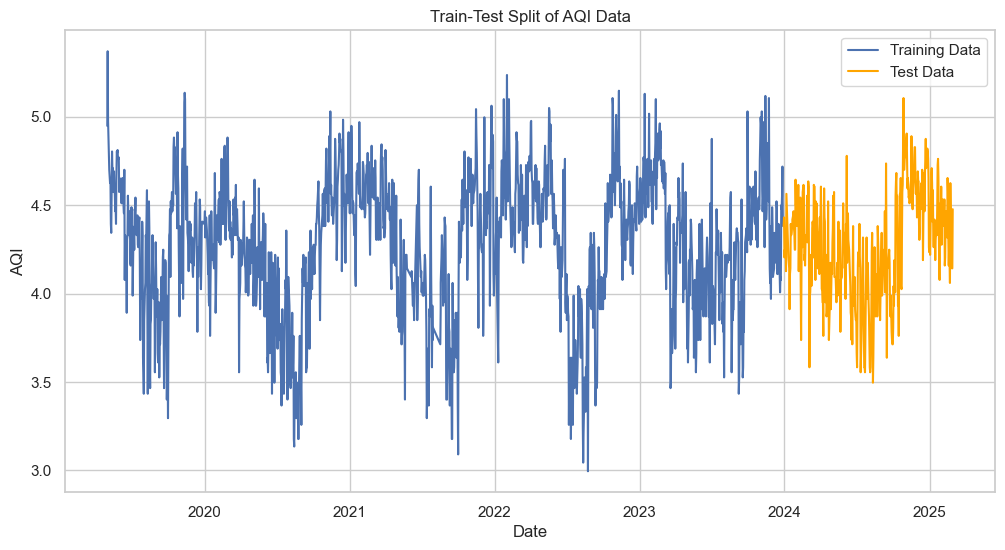

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Test Data', color='orange')
plt.title('Train-Test Split of AQI Data')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

RMSE: 4.28
MAE: 4.27


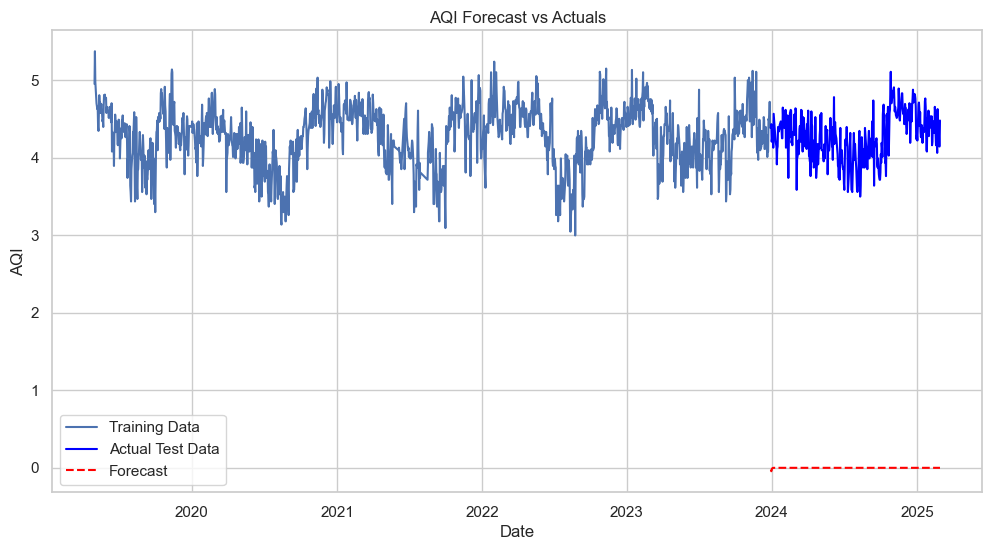

In [ ]:
forecast_steps = len(test)
forecast = best_model.forecast(steps=forecast_steps)
forecast_values = np.exp(forecast) - 1
actuals = test.dropna().values
forecast_values = forecast_values[:len(actuals)]
actuals = test.dropna().values
mse = mean_squared_error(actuals, forecast_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, forecast_values)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data', color='blue')
plt.plot(test.index, forecast_values, label='Forecast', color='red', linestyle='--')
plt.title('AQI Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model = sm.tsa.ARIMA(train, order=(2, 1, 1))
results = model.fit()

residuals = results.resid
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Ljung-Box Test Results:\n", lb_test)

Ljung-Box Test Results:
      lb_stat  lb_pvalue
10  2.432395   0.991825


**Ljung-Box test**

Here p value is > 0.05 by, so we are rejecting the hypothesis that is our residuals are not correlated. So cannot predict anything from this.


## SARIMA


<Figure size 1400x600 with 0 Axes>

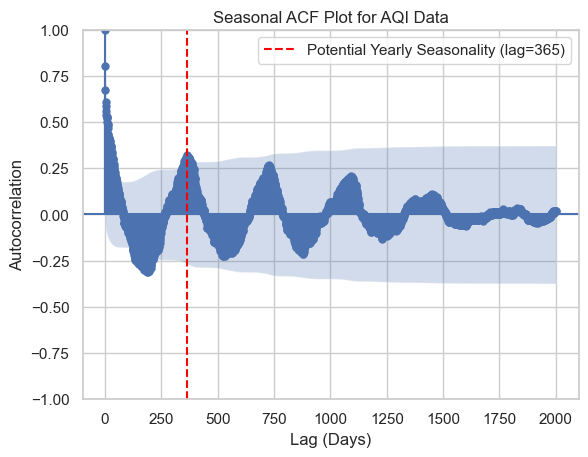

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))
plot_acf(df['AQI'], lags=2000, alpha=0.05)
plt.axvline(x=365, color='red', linestyle='--', label='Potential Yearly Seasonality (lag=365)')
plt.title('Seasonal ACF Plot for AQI Data')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(True)
plt.show()

From this we can say that Our model had **yearly** seasonality. Because it has bigger spike at 365,730,...


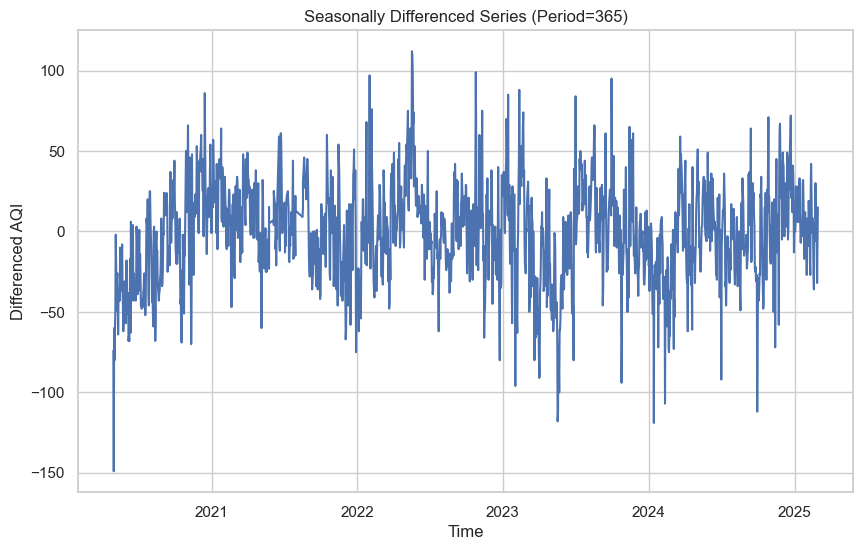

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

seasonal_period = 365

seasonal_diff = df['AQI'] - df['AQI'].shift(seasonal_period)

seasonal_diff = seasonal_diff.dropna()

plt.figure(figsize=(10, 6))
plt.plot(seasonal_diff)
plt.title(f"Seasonally Differenced Series (Period={seasonal_period})")
plt.xlabel("Time")
plt.ylabel("Differenced AQI")
plt.grid(True)
plt.show()


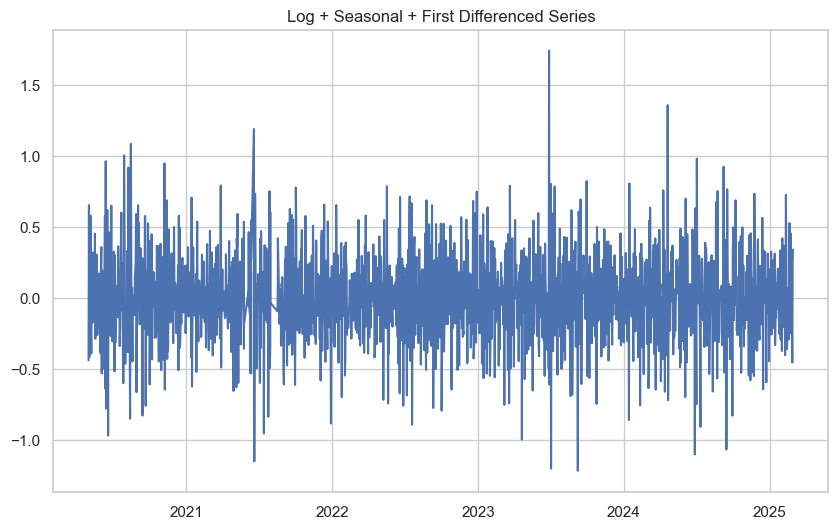

In [ ]:
import numpy as np

log_series = np.log(df['AQI'])

log_seasonal_diff = log_series - log_series.shift(seasonal_period)

final_stationary = log_seasonal_diff - log_seasonal_diff.shift(1)
final_stationary = final_stationary.dropna()

plt.figure(figsize=(10, 6))
plt.plot(final_stationary)
plt.title("Log + Seasonal + First Differenced Series")
plt.grid(True)
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(seasonal_diff.dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series may still be non-stationary.")

ADF Statistic: -7.2307479022898775
p-value: 1.9976863137272489e-10
Series is stationary.


In [ ]:
# import itertools
# import statsmodels.api as sm
# import numpy as np
# import warnings
# warnings.filterwarnings("ignore")

# # Fixed non-seasonal order from your ARIMA model
# order = (2, 1, 1)

# # Seasonal parameter ranges to test
# P = Q = range(0, 3)   # Try values 0 to 2 for P and Q
# D = 1
# s = 30

# # Generate combinations of seasonal parameters
# seasonal_orders = list(itertools.product(P, [D], Q, [s]))

# # Initialize tracking variables
# best_aic = np.inf
# best_seasonal_order = None
# best_model = None

# # Loop through seasonal parameter combinations
# for seasonal_order in seasonal_orders:
#     try:
#         model = sm.tsa.SARIMAX(log_series,
#                                order=order,
#                                seasonal_order=seasonal_order,
#                                enforce_stationarity=False,
#                                enforce_invertibility=False)

#         results = model.fit(disp=False)
#         print(f"Trying seasonal_order={seasonal_order}, AIC={results.aic:.2f}")

#         if results.aic < best_aic:
#             best_aic = results.aic
#             best_seasonal_order = seasonal_order
#             best_model = results
#     except Exception as e:
#         print(f"Failed seasonal_order={seasonal_order}: {e}")
#         continue

# # Final output
# print(f"\nBest seasonal_order: {best_seasonal_order} with AIC = {best_aic}")

In [ ]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# import time

# start_time = time.time()

# # Reduced order parameters (avoids overfitting)
# try:
#     model = SARIMAX(df['AQI'],
#                   order=(2,1,0),           # Non-seasonal (p,d,q)
#                   seasonal_order=(0,1,1,365), # Seasonal (P,D,Q,s)
#                   enforce_stationarity=False,
#                   enforce_invertibility=False,
#                   simple_differencing=True).fit(disp=False)

#     print(f"Model fitted in {time.time()-start_time:.1f} seconds")
#     print(model.summary())

# except Exception as e:
#     print(f"Failed: {str(e)}")

<Figure size 1200x600 with 0 Axes>

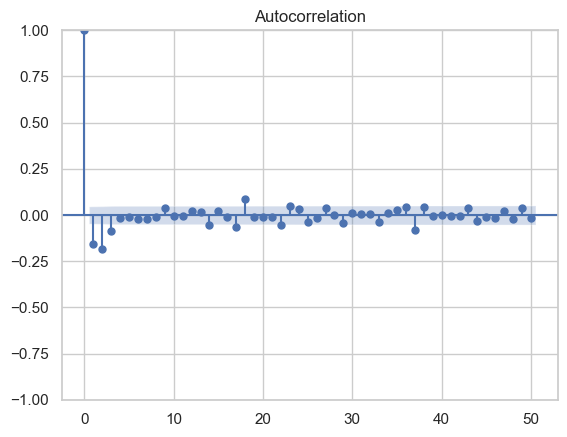

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 6))
plot_acf(final_stationary, lags=50)
plt.show()


The ACF shows no correlations extending beyond the blue confidence bands at any lag (including lag 10, 20, etc.).

This suggests your transformations successfully removed seasonality and trends, leaving only random noise.

Slight negative autocorrelation at early lags (common after over-differencing).


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(final_stationary.dropna(), order=(2,1,1)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1765
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -384.129
Date:                Tue, 22 Apr 2025   AIC                            776.258
Time:                        22:06:25   BIC                            798.160
Sample:                             0   HQIC                           784.351
                               - 1765                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1890      0.021     -9.040      0.000      -0.230      -0.148
ar.L2         -0.2112      0.023     -9.233      0.000      -0.256      -0.166
ma.L1         -1.0000      0.745     -1.343      0.1

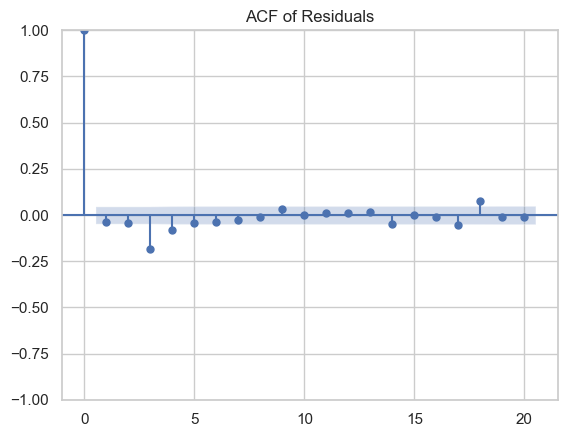

In [ ]:
residuals = model.resid
plot_acf(residuals, lags=20)
plt.title('ACF of Residuals')
plt.show()

RMSE: 0.25
MAE: 0.21


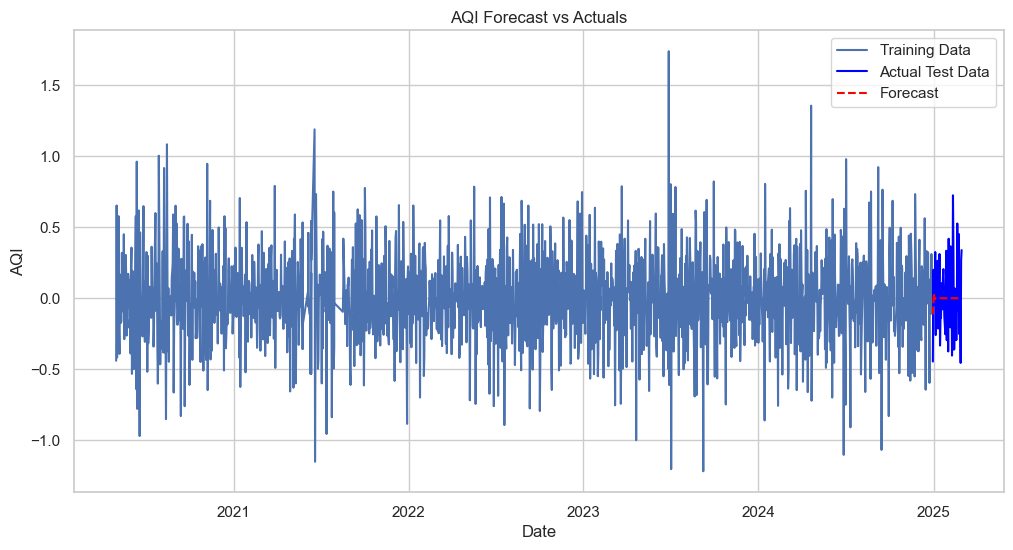

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

split_point = int(len(df) * 0.8)

train = final_stationary.iloc[:split_point]
test = final_stationary.iloc[split_point:]

forecast_steps = len(test)
forecast = model.forecast(steps=forecast_steps)

forecast_values = np.exp(forecast) - 1

actuals = test.dropna().values
forecast_values = forecast_values[:len(actuals)]

actuals = test.dropna().values
mse = mean_squared_error(actuals, forecast_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, forecast_values)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data', color='blue')
plt.plot(test.index, forecast_values, label='Forecast', color='red', linestyle='--')
plt.title('AQI Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

After removing seasonality we able to minimize the error.


We cannot implement the SARIMAX due to high seasonal period(365).


## Deep Learning Models - RNN, LSTM, GRU


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Krishil-Jayswal/AQI-Forecasting/refs/heads/main/2.%20Data%20Preprocessing/full_aqi_dataset.csv")
data = df['AQI'].values.reshape(-1, 1)

window_size = 30
batch_size = 32
hidden_size = 64
num_epochs = 100
learning_rate = 0.001

In [ ]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y))

In [ ]:
train_size = int(0.8 * len(data))
train_data = data[:train_size]
test_data = data[train_size:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

test_sequences_input = np.concatenate([train_scaled[-window_size:], test_scaled])
X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_sequences_input, window_size)

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [ ]:
def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

In [ ]:
def train_model(model, model_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    test_losses = []

    print(f"\nTraining {model_name}...")
    for epoch in range(num_epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()


        model.eval()
        with torch.no_grad():
            train_preds = model(X_train)
            test_preds = model(X_test)
            train_loss = criterion(train_preds, y_train)
            test_loss = criterion(test_preds, y_test)

            train_losses.append(train_loss.item())
            test_losses.append(test_loss.item())

        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

    plt.figure(figsize=(10,6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    model.eval()
    with torch.no_grad():
        train_preds = model(X_train).numpy()
        test_preds = model(X_test).numpy()

        y_train_actual = scaler.inverse_transform(y_train.numpy())
        y_test_actual = scaler.inverse_transform(y_test.numpy())
        train_preds = scaler.inverse_transform(train_preds)
        test_preds = scaler.inverse_transform(test_preds)

        train_metrics = calculate_metrics(y_train_actual, train_preds)
        test_metrics = calculate_metrics(y_test_actual, test_preds)

        print(f"\n{model_name} Training Metrics:")
        for metric, value in train_metrics.items():
            print(f"{metric}: {value:.4f}")

        print(f"\n{model_name} Test Metrics:")
        for metric, value in test_metrics.items():
            print(f"{metric}: {value:.4f}")

        return model, train_metrics, test_metrics


Training RNN...
Epoch [10/100], Train Loss: 0.0063, Test Loss: 0.0052
Epoch [20/100], Train Loss: 0.0064, Test Loss: 0.0054
Epoch [30/100], Train Loss: 0.0067, Test Loss: 0.0057
Epoch [40/100], Train Loss: 0.0066, Test Loss: 0.0054
Epoch [50/100], Train Loss: 0.0061, Test Loss: 0.0050
Epoch [60/100], Train Loss: 0.0067, Test Loss: 0.0057
Epoch [70/100], Train Loss: 0.0062, Test Loss: 0.0051
Epoch [80/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [90/100], Train Loss: 0.0062, Test Loss: 0.0052
Epoch [100/100], Train Loss: 0.0061, Test Loss: 0.0051


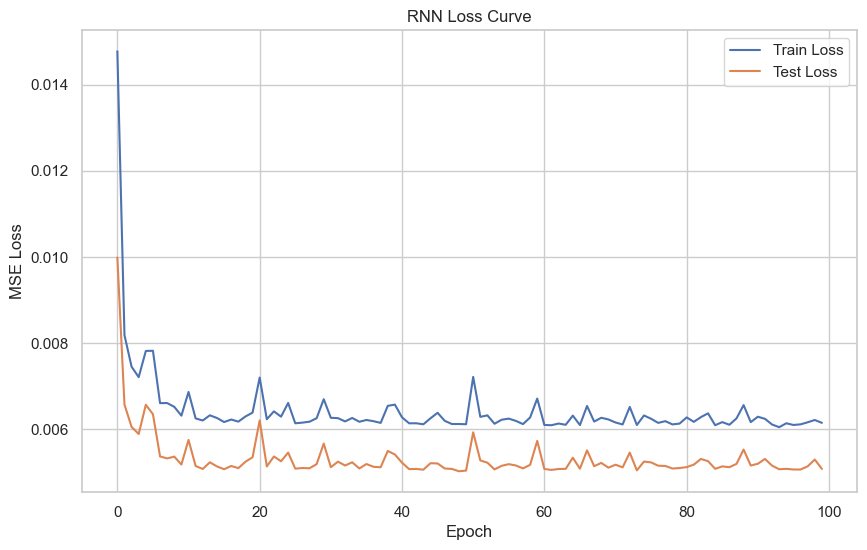


RNN Training Metrics:
MSE: 233.8438
RMSE: 15.2920
MAE: 10.9470
R2: 0.6800
MAPE: 15.8398

RNN Test Metrics:
MSE: 193.1845
RMSE: 13.8991
MAE: 10.6379
R2: 0.5998
MAPE: 15.1847


In [ ]:
rnn_model, rnn_train_metrics, rnn_test_metrics = train_model(RNNModel(), "RNN")


Training GRU...
Epoch [10/100], Train Loss: 0.0070, Test Loss: 0.0058
Epoch [20/100], Train Loss: 0.0062, Test Loss: 0.0050
Epoch [30/100], Train Loss: 0.0065, Test Loss: 0.0054
Epoch [40/100], Train Loss: 0.0062, Test Loss: 0.0051
Epoch [50/100], Train Loss: 0.0063, Test Loss: 0.0053
Epoch [60/100], Train Loss: 0.0064, Test Loss: 0.0053
Epoch [70/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [80/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [90/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [100/100], Train Loss: 0.0061, Test Loss: 0.0052


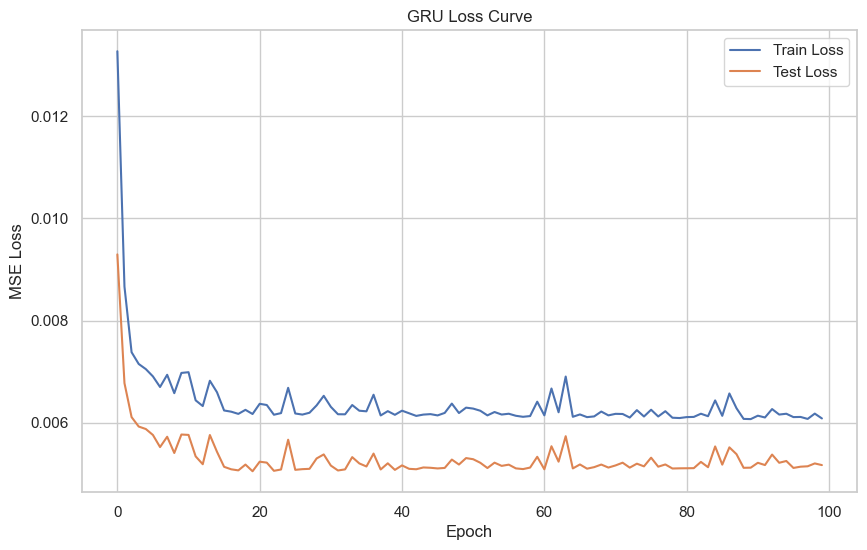


GRU Training Metrics:
MSE: 231.3259
RMSE: 15.2094
MAE: 11.0091
R2: 0.6835
MAPE: 16.3535

GRU Test Metrics:
MSE: 196.5986
RMSE: 14.0214
MAE: 10.7742
R2: 0.5927
MAPE: 15.8821


In [ ]:
gru_model, gru_train_metrics, gru_test_metrics = train_model(GRUModel(), "GRU")


Training LSTM...
Epoch [10/100], Train Loss: 0.0074, Test Loss: 0.0061
Epoch [20/100], Train Loss: 0.0064, Test Loss: 0.0053
Epoch [30/100], Train Loss: 0.0062, Test Loss: 0.0051
Epoch [40/100], Train Loss: 0.0062, Test Loss: 0.0051
Epoch [50/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [60/100], Train Loss: 0.0062, Test Loss: 0.0051
Epoch [70/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [80/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [90/100], Train Loss: 0.0061, Test Loss: 0.0051
Epoch [100/100], Train Loss: 0.0061, Test Loss: 0.0051


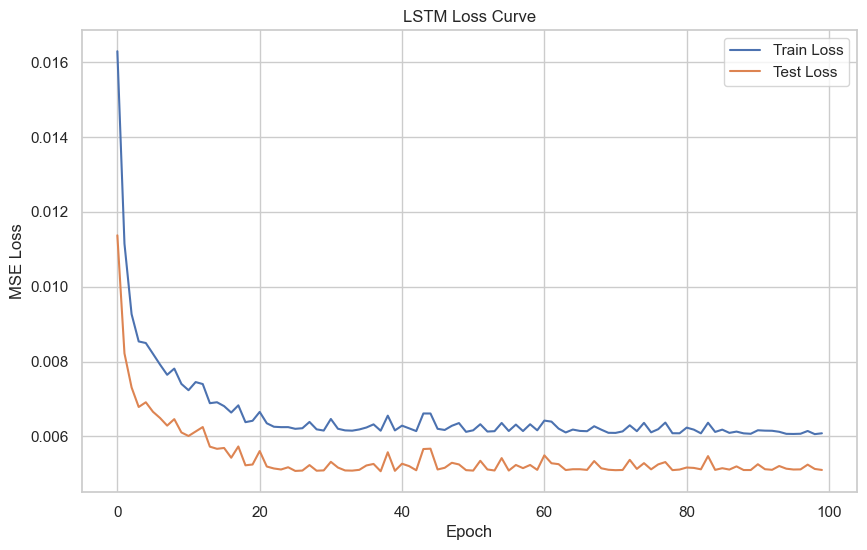


LSTM Training Metrics:
MSE: 231.3850
RMSE: 15.2113
MAE: 10.9737
R2: 0.6834
MAPE: 16.3730

LSTM Test Metrics:
MSE: 194.1584
RMSE: 13.9341
MAE: 10.7423
R2: 0.5978
MAPE: 15.8021


In [ ]:
lstm_model, lstm_train_metrics, lstm_test_metrics = train_model(LSTMModel(), "LSTM")

In [ ]:
def create_metrics_table(train_metrics, test_metrics, model_name):
    df = pd.DataFrame({
        'Metric': list(train_metrics.keys()),
        f'{model_name} Train': list(train_metrics.values()),
        f'{model_name} Test': list(test_metrics.values())
    })
    return df

rnn_df = create_metrics_table(rnn_train_metrics, rnn_test_metrics, "RNN")
gru_df = create_metrics_table(gru_train_metrics, gru_test_metrics, "GRU")
lstm_df = create_metrics_table(lstm_train_metrics, lstm_test_metrics, "LSTM")

final_df = rnn_df.merge(gru_df, on='Metric').merge(lstm_df, on='Metric')
print("\nModel Performance Comparison:")
print(final_df.to_string(index=False))


Model Performance Comparison:
Metric  RNN Train   RNN Test  GRU Train   GRU Test  LSTM Train  LSTM Test
   MSE 233.843781 193.184464 231.325897 196.598618  231.385010 194.158401
  RMSE  15.291951  13.899081  15.209401  14.021363   15.211345  13.934073
   MAE  10.947032  10.637866  11.009124  10.774215   10.973748  10.742310
    R2   0.680035   0.599768   0.683480   0.592695    0.683399   0.597750
  MAPE  15.839823  15.184678  16.353528  15.882087   16.372976  15.802088


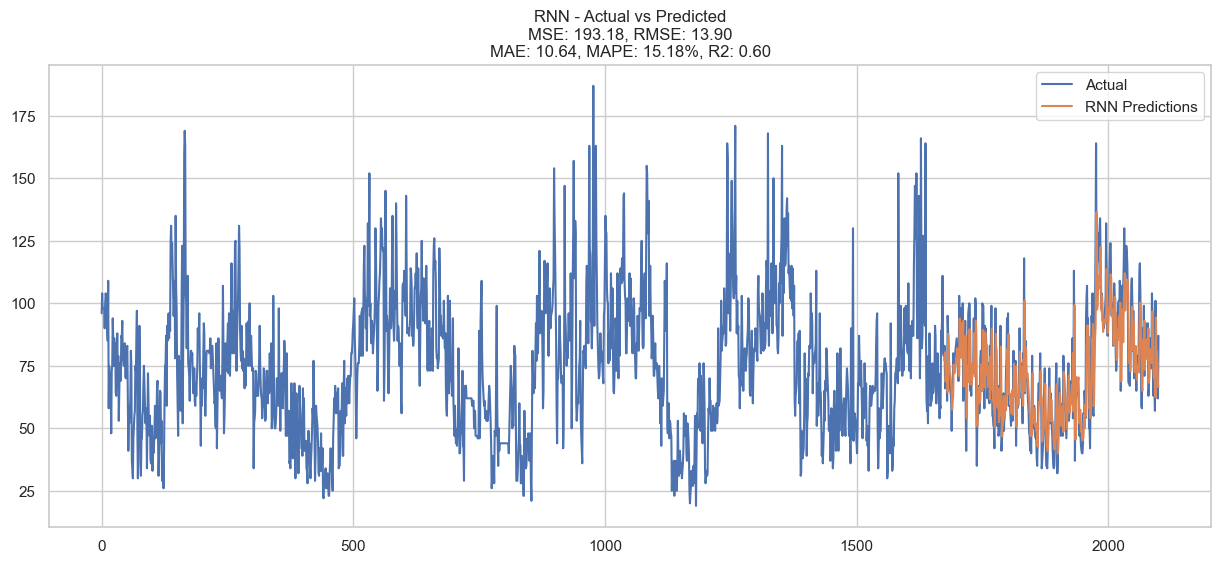

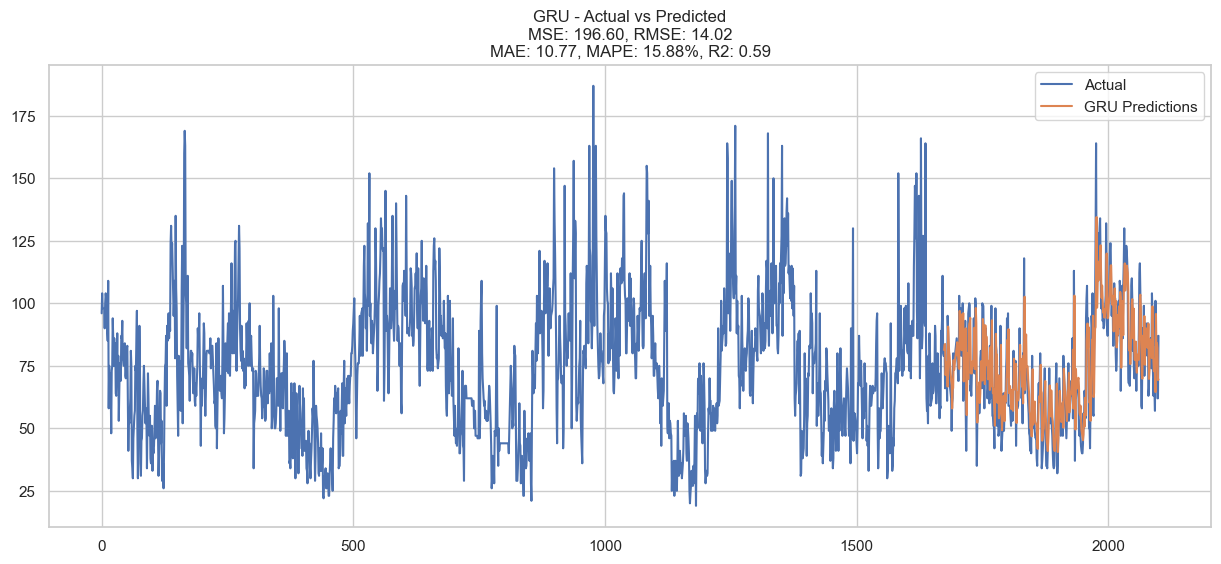

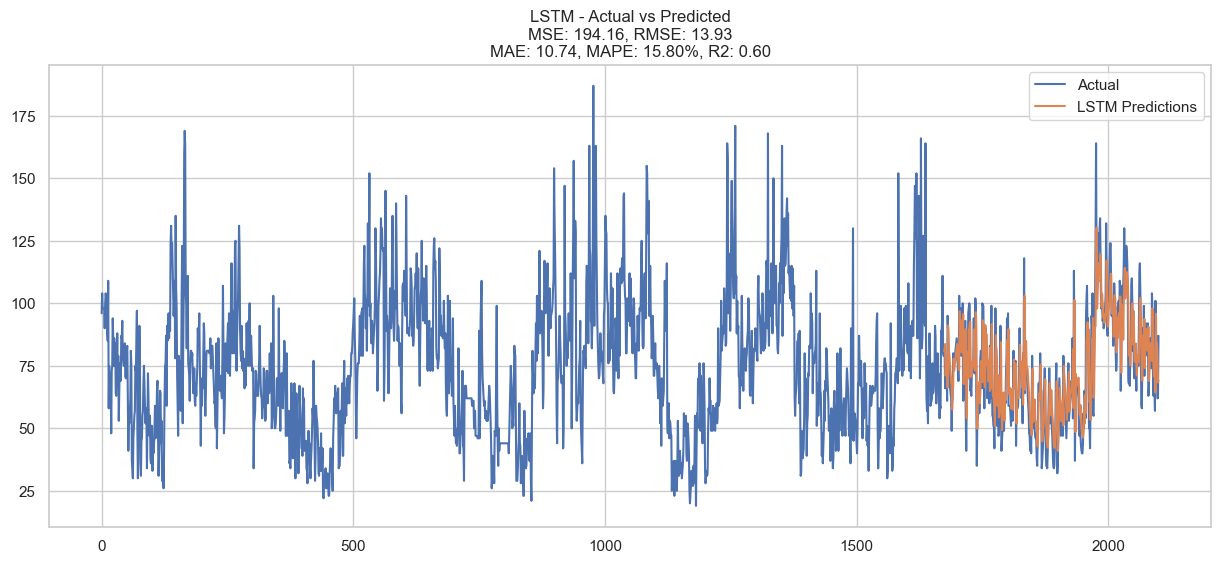

In [ ]:
def plot_predictions(model, model_name, metrics):
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train).numpy()
        test_preds = model(X_test).numpy()

    train_preds = scaler.inverse_transform(train_preds)
    test_preds = scaler.inverse_transform(test_preds)
    actual = scaler.inverse_transform(np.concatenate([y_train.numpy(), y_test.numpy()]))

    plt.figure(figsize=(15, 6))
    plt.plot(actual, label='Actual')
    plt.plot([None]*len(y_train) + test_preds.flatten().tolist(), label=f'{model_name} Predictions')

    title_metrics = f"MSE: {metrics['MSE']:.2f}, RMSE: {metrics['RMSE']:.2f}\nMAE: {metrics['MAE']:.2f}, MAPE: {metrics['MAPE']:.2f}%, R2: {metrics['R2']:.2f}"
    plt.title(f'{model_name} - Actual vs Predicted\n{title_metrics}')
    plt.legend()
    plt.show()

plot_predictions(rnn_model, "RNN", rnn_test_metrics)
plot_predictions(gru_model, "GRU", gru_test_metrics)
plot_predictions(lstm_model, "LSTM", lstm_test_metrics)

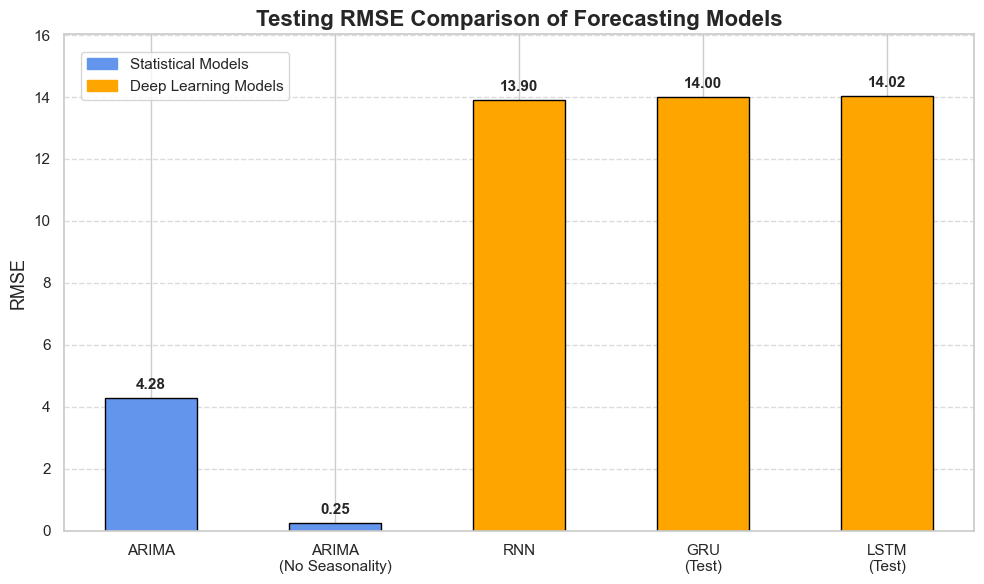

In [ ]:
models = ['ARIMA', 'ARIMA\n(No Seasonality)', 'RNN', 'GRU\n(Test)', 'LSTM\n(Test)']
rmse_values = [4.28, 0.25, 13.90, 14.0043, 14.02]
colors = ['cornflowerblue', 'cornflowerblue', 'orange', 'orange', 'orange']

plt.figure(figsize=(10, 6))
bar_width = 0.5
bars = plt.bar(models, rmse_values, width=bar_width, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Testing RMSE Comparison of Forecasting Models', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

custom_legend = [
    plt.Rectangle((0, 0), 1, 1, color='cornflowerblue', edgecolor='black', label='Statistical Models'),
    plt.Rectangle((0, 0), 1, 1, color='orange', edgecolor='black', label='Deep Learning Models')
]
plt.legend(handles=custom_legend, loc='upper left', bbox_to_anchor=(0.01, 0.98), fontsize=11)

plt.ylim(0, max(rmse_values) + 2)
plt.tight_layout()
plt.show()


In [2]:
pip install pyemd tensorflow pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 666.6/666.6 kB 12.9 MB/s eta 0:00:00


In [5]:
!pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.5 MB/s eta 0:00:00


## **Empirical Mode Decomposition + Deep Learning Models**


<ipython-input-8-03107e15f3b3>:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(original_series[i])
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM...
Epoch  10 | Loss: 0.0096 | Val Loss: 0.0108
Epoch  20 | Loss: 0.0079 | Val Loss: 0.0093
Epoch  30 | Loss: 0.0061 | Val Loss: 0.0075
Epoch  40 | Loss: 0.0046 | Val Loss: 0.0079
Epoch  50 | Loss: 0.0039 | Val Loss: 0.0053
Epoch  60 | Loss: 0.0033 | Val Loss: 0.0049
Epoch  70 | Loss: 0.0032 | Val Loss: 0.0046
Epoch  80 | Loss: 0.0029 | Val Loss: 0.0044
Epoch  90 | Loss: 0.0028 | Val Loss: 0.0046
Epoch 100 | Loss: 0.0027 | Val Loss: 0.0048

Training GRU...
Epoch  10 | Loss: 0.0074 | Val Loss: 0.0082
Epoch  20 | Loss: 0.0041 | Val Loss: 0.0061
Epoch  30 | Loss: 0.0034 | Val Loss: 0.0049
Epoch  40 | Loss: 0.0032 | Val Loss: 0.0046
Epoch  50 | Loss: 0.0031 | Val Loss: 0.0043
Epoch  60 | Loss: 0.0029 | Val Loss: 0.0041
Epoch  70 | Loss: 0.0030 | Val Loss: 0.0042
Epoch  80 | Loss: 0.0028 | Val Loss: 0.0041
Epoch  90 | Loss: 0.0026 | Val Loss: 0.0041
Epoch 100 | Loss: 0.0028 | Val Loss: 0.0041

Training RNN...
Epoch  10 | Loss: 0.0062 | Val Loss: 0.0070
Epoch  20 | Loss: 0.0044

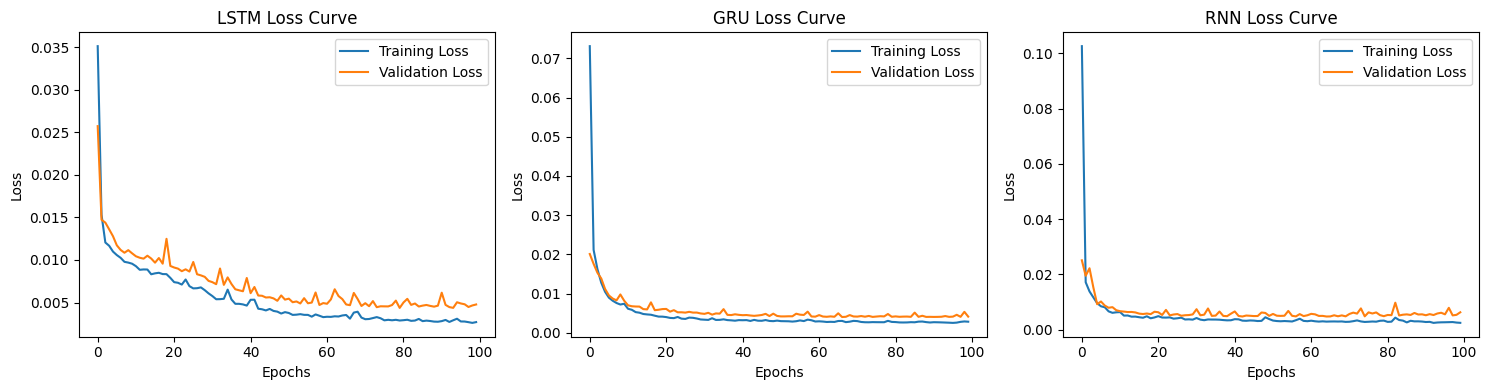

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

Performance Metrics:
          MAE    RMSE     R2
Model                       
LSTM  10.9235 13.3600 0.6350
GRU    7.5504  9.4723 0.8165
RNN    9.7138 11.8987 0.7105


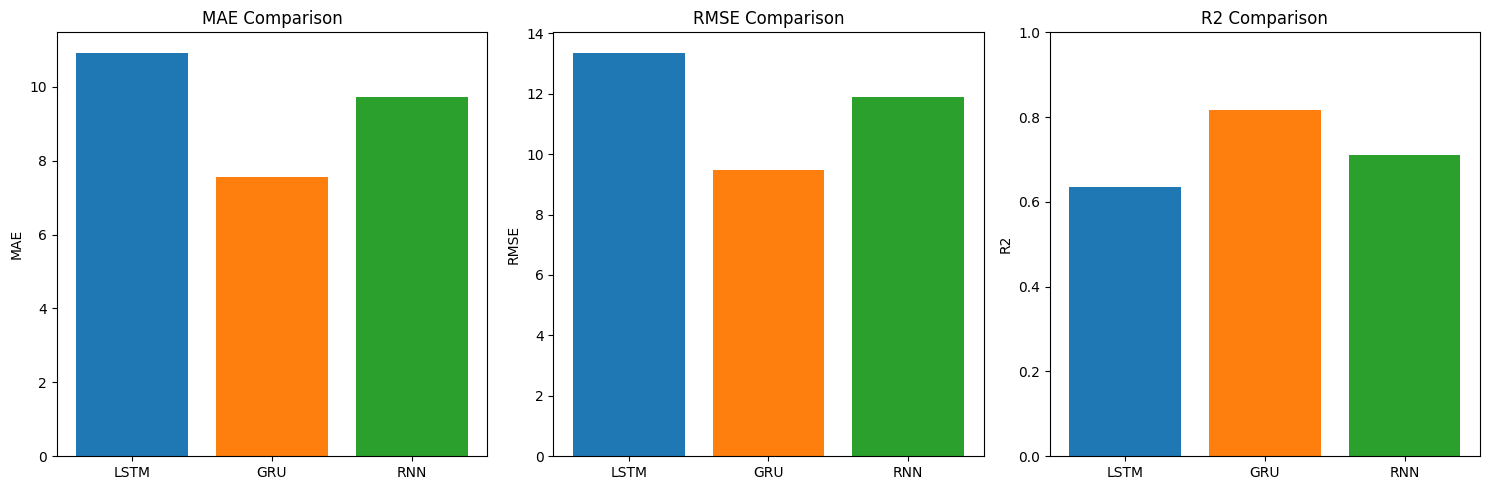

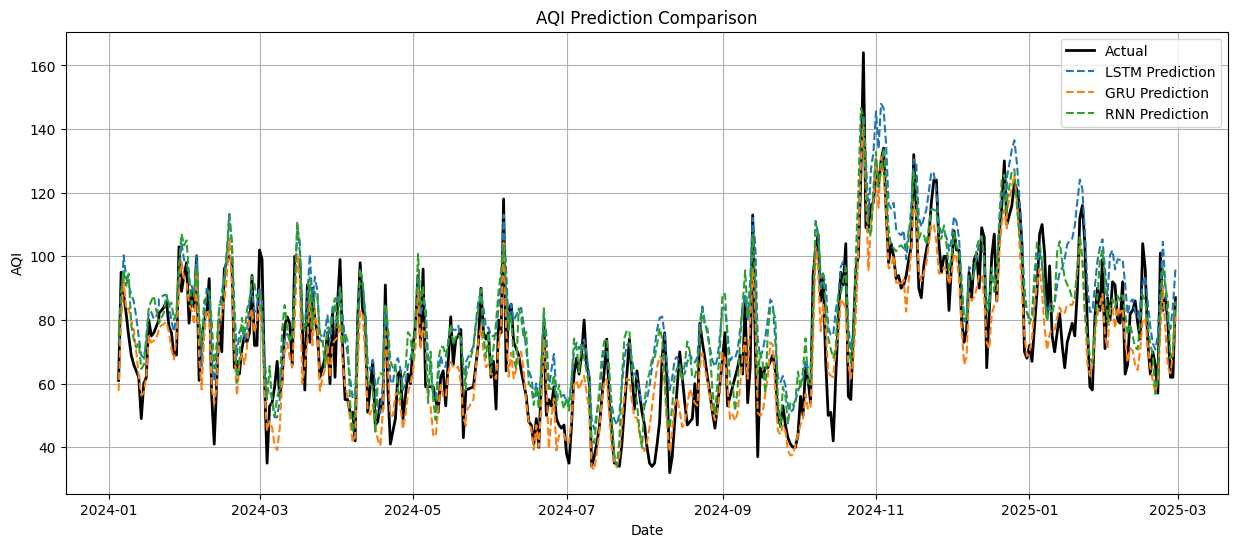

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, SimpleRNN, Dense
from tensorflow.keras.callbacks import LambdaCallback

def decompose_aqi(series):
    emd = EMD()
    imfs = emd(series.values.ravel())
    return imfs

def preprocess_data(imfs, original_series, n_steps=30):
    imf_scalers = [MinMaxScaler(feature_range=(0, 1)) for _ in imfs]
    scaled_imfs = [scaler.fit_transform(imf.reshape(-1, 1))
                   for imf, scaler in zip(imfs, imf_scalers)]

    X, y = [], []
    for i in range(n_steps, len(original_series)):
        X.append(np.hstack([imf[i-n_steps:i] for imf in scaled_imfs]))
        y.append(original_series[i])

    X = np.array(X)
    y = np.array(y)

    target_scaler = MinMaxScaler()
    y = target_scaler.fit_transform(y.reshape(-1, 1))

    return X, y, imf_scalers, target_scaler

def train_test_split(X, y, split_ratio=0.8):
    split = int(split_ratio * len(X))
    return X[:split], X[split:], y[:split], y[split:]

def build_model(model_type, input_shape):
    model = Sequential()

    if model_type == 'GRU':
        model.add(GRU(64, return_sequences=True, input_shape=input_shape))
        model.add(GRU(32))
    elif model_type == 'LSTM':
        model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
        model.add(LSTM(32))
    elif model_type == 'RNN':
        model.add(SimpleRNN(64, return_sequences=True, input_shape=input_shape))
        model.add(SimpleRNN(32))

    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def main():
    url = "https://raw.githubusercontent.com/Krishil-Jayswal/AQI-Forecasting/refs/heads/main/2.%20Data%20Preprocessing/full_aqi_dataset.csv"
    data = pd.read_csv(url, usecols=['Date', 'AQI'], parse_dates=['Date'], index_col='Date')
    aqi_series = data['AQI'].squeeze()
    imfs = decompose_aqi(aqi_series)
    X, y, imf_scalers, target_scaler = preprocess_data(imfs, aqi_series)
    X_train, X_test, y_train, y_test = train_test_split(X, y)

    progress_callback = LambdaCallback(
        on_epoch_end=lambda epoch, logs:
        (epoch + 1) % 10 == 0 and print(
            f"Epoch {epoch+1:3d} | Loss: {logs['loss']:.4f} | Val Loss: {logs['val_loss']:.4f}"
        )
    )

    models = {}
    for model_type in ['LSTM', 'GRU', 'RNN']:
        print(f"\nTraining {model_type}...")
        model = build_model(model_type, (X_train.shape[1], X_train.shape[2]))
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            validation_split=0.2,
            verbose=0,
            callbacks=[progress_callback]
        )
        models[model_type] = {
            'model': model,
            'history': history.history
        }

    plt.figure(figsize=(15, 4))
    for idx, (name, data) in enumerate(models.items(), 1):
        plt.subplot(1, 3, idx)
        plt.plot(data['history']['loss'], label='Training Loss')
        plt.plot(data['history']['val_loss'], label='Validation Loss')
        plt.title(f'{name} Loss Curve')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
    plt.tight_layout()
    plt.show()

    predictions = {}
    y_test_actual = target_scaler.inverse_transform(y_test)

    for name, model_data in models.items():
        y_pred = model_data['model'].predict(X_test)
        predictions[name] = target_scaler.inverse_transform(y_pred)

    metrics = []
    for name, y_pred in predictions.items():
        metrics.append({
            'Model': name,
            'MAE': mean_absolute_error(y_test_actual, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test_actual, y_pred)),
            'R2': r2_score(y_test_actual, y_pred)
        })

    metrics_df = pd.DataFrame(metrics).set_index('Model')
    print("\nPerformance Metrics:")
    print(metrics_df.to_string(float_format="%.4f"))

    plt.figure(figsize=(15, 5))
    for idx, metric in enumerate(['MAE', 'RMSE', 'R2'], 1):
        plt.subplot(1, 3, idx)
        plt.bar(metrics_df.index, metrics_df[metric], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        plt.title(f'{metric} Comparison')
        plt.ylabel(metric)
        if metric == 'R2':
            plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 6))
    plt.plot(aqi_series.index[-len(y_test_actual):], y_test_actual,
             label='Actual', linewidth=2, color='black')
    for name, y_pred in predictions.items():
        plt.plot(aqi_series.index[-len(y_pred):], y_pred,
                 linestyle='--', label=f'{name} Prediction')
    plt.title('AQI Prediction Comparison')
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()